# GWP3: Portfolio Management with ML Improvements

This notebook implements:
- Step 1: Baseline portfolio optimization
- Step 2: Three improvement methods (Denoising CREM, Clustering HRP, Backtesting)
- Step 3: Method combinations
- Step 4: Performance comparison
- Step 5: Out-of-sample testing


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configuration
TICKERS = [
    'AAPL', 'MSFT', 'NVDA', 'JPM', 'V',
    'JNJ', 'PFE', 'AMZN', 'TSLA', 'PG',
    'WMT', 'UNP', 'BA', 'LIN', 'XOM',
    'GOOGL', 'META', 'NEE', 'PLD', 'GLD'
]

TRAIN_START = "2024-01-01"
TRAIN_END = "2025-06-30"
TEST_START = "2025-07-01"
TEST_END = "2025-07-31"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Assets: {len(TICKERS)}")
print(f"Training period: {TRAIN_START} to {TRAIN_END}")
print(f"Test period: {TEST_START} to {TEST_END}")


Assets: 20
Training period: 2024-01-01 to 2025-06-30
Test period: 2025-07-01 to 2025-07-31


In [2]:
# Data fetching function using yfinance
def fetch_prices_yfinance(tickers, start, end):
    """Fetch price data using yfinance"""
    data = yf.download(tickers, start=start, end=end, progress=False)
    
    # Handle multi-level columns if needed
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Close']
    else:
        prices = data
    
    # Ensure all tickers are present
    missing = [t for t in tickers if t not in prices.columns]
    if missing:
        print(f"Warning: Missing data for {missing}")
    
    # Only use available tickers
    available_tickers = [t for t in tickers if t in prices.columns]
    if len(available_tickers) == 0:
        print(f"ERROR: No data available for any ticker!")
        return pd.DataFrame()
    
    prices = prices[available_tickers]
    
    # Filter by date range explicitly
    if len(prices) > 0:
        prices = prices.loc[(prices.index >= pd.Timestamp(start)) & (prices.index <= pd.Timestamp(end))]
    
    # Drop rows where ALL values are NaN (but keep rows with some NaN)
    prices = prices.dropna(how='all')
    
    return prices

# Fetch data
print("Fetching price data...")
prices_all = fetch_prices_yfinance(TICKERS, TRAIN_START, TEST_END)

# Split into train and test from the full dataset
if len(prices_all) > 0:
    prices_train = prices_all.loc[(prices_all.index >= pd.Timestamp(TRAIN_START)) & 
                                   (prices_all.index <= pd.Timestamp(TRAIN_END))]
    prices_test = prices_all.loc[(prices_all.index >= pd.Timestamp(TEST_START)) & 
                                  (prices_all.index <= pd.Timestamp(TEST_END))]
else:
    print("ERROR: No data fetched! Check internet connection and ticker symbols.")
    prices_train = pd.DataFrame()
    prices_test = pd.DataFrame()

print(f"Training data shape: {prices_train.shape}")
print(f"Test data shape: {prices_test.shape}")
print(f"All data shape: {prices_all.shape}")

# Calculate returns
def compute_returns(prices):
    """Calculate log returns"""
    returns = np.log(prices / prices.shift(1)).dropna()
    return returns

returns_train = compute_returns(prices_train)
returns_test = compute_returns(prices_test)
returns_all = compute_returns(prices_all)

print(f"\nReturns calculated:")
print(f"Training returns: {returns_train.shape}")
print(f"Test returns: {returns_test.shape}")

# Data quality checks
print("\n" + "=" * 60)
print("Data Quality Checks:")
print("=" * 60)
print(f"Missing values in training returns: {returns_train.isnull().sum().sum()}")
print(f"Zero returns in training: {(returns_train == 0).sum().sum()}")
# Data quality checks with error handling
print(f"Missing values in training returns: {returns_train.isna().sum().sum()}")
print(f"Zero returns in training: {(returns_train == 0).sum().sum()}")
if len(returns_train) > 0:
    print(f"Extreme returns (>10% daily) in training: {(returns_train.abs() > 0.10).sum().sum()}")
    print(f"\nTraining period statistics:")
    print(f"  Date range: {returns_train.index[0]} to {returns_train.index[-1]}")
    print(f"  Number of trading days: {len(returns_train)}")
    print(f"  Mean daily return range: [{returns_train.mean().min():.4f}, {returns_train.mean().max():.4f}]")
    print(f"  Volatility range: [{returns_train.std().min():.4f}, {returns_train.std().max():.4f}]")
else:
    print("\nWARNING: Training returns is empty! Check data fetching.")


Fetching price data...
Training data shape: (374, 20)
Test data shape: (21, 20)
All data shape: (395, 20)

Returns calculated:
Training returns: (373, 20)
Test returns: (20, 20)

Data Quality Checks:
Missing values in training returns: 0
Zero returns in training: 15
Missing values in training returns: 0
Zero returns in training: 15
Extreme returns (>10% daily) in training: 26

Training period statistics:
  Date range: 2024-01-03 00:00:00 to 2025-06-30 00:00:00
  Number of trading days: 373
  Mean daily return range: [-0.0005, 0.0032]
  Volatility range: [0.0106, 0.0425]


In [3]:
# Reuse optimization functions from GWP2
def negative_sharpe(weights, mean_returns, cov_matrix):
    """Negative Sharpe ratio for minimization"""
    portfolio_return = float(np.dot(weights, mean_returns))
    portfolio_vol = float(np.sqrt(weights @ cov_matrix @ weights))
    if portfolio_vol == 0:
        return 1e6
    return -(portfolio_return / portfolio_vol)

def optimize_portfolio(mean_returns, cov_matrix, bounds, allow_short=False):
    """Optimize portfolio weights"""
    n = len(mean_returns)
    x0 = np.repeat(1 / n, n)
    
    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    
    if allow_short and bounds is None:
        # Analytical solution for unconstrained case
        inv_cov = np.linalg.inv(cov_matrix)
        weights = inv_cov @ mean_returns
        weights = weights / np.sum(weights)
        return weights
    
    result = minimize(
        negative_sharpe,
        x0,
        args=(mean_returns, cov_matrix),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )
    if not result.success:
        raise RuntimeError(f"Optimization failed: {result.message}")
    return result.x

def apply_weight_constraints(weights, min_weight=0, max_weight=0.15):
    """Apply weight constraints and re-normalize weights to sum to 1"""
    weights = np.clip(weights, min_weight, max_weight)
    weights = weights / np.sum(weights)
    return weights

print("Optimization functions defined")

# ===== Helper Functions for Visualization =====
def plot_cumulative_returns(returns_dict, title, save_path):
    """Plot cumulative returns comparison with improved color scheme"""
    # Find union of all indices to handle different date ranges (for walk-forward)
    all_indices = set()
    for returns in returns_dict.values():
        all_indices.update(returns.index)
    all_indices = sorted(all_indices)
    
    cumulative = pd.DataFrame(index=all_indices)
    for name, returns in returns_dict.items():
        # Align returns to common index
        returns_aligned = pd.Series(index=all_indices, dtype=float)
        returns_aligned.loc[returns.index] = returns
        
        # Calculate cumulative returns only for valid (non-NaN) values
        # For NaN values, keep NaN so the line will skip those dates
        valid_mask = returns_aligned.notna()
        if valid_mask.sum() > 0:
            # Start cumulative from first valid date
            first_valid_idx = valid_mask.idxmax()
            cum_returns = pd.Series(index=all_indices, dtype=float)
            
            # Calculate cumulative from first valid date
            valid_returns = returns_aligned.loc[first_valid_idx:]
            cum_values = (1 + valid_returns).cumprod()
            cum_returns.loc[first_valid_idx:] = cum_values
            
            cumulative[name] = cum_returns
    
    # Define a color palette with high contrast and distinct colors
    # Using a combination of distinct colors that are easy to distinguish
    color_palette = [
        '#1f77b4',  # Blue
        '#ff7f0e',  # Orange
        '#2ca02c',  # Green
        '#d62728',  # Red
        '#9467bd',  # Purple
        '#8c564b',  # Brown
        '#e377c2',  # Pink
        '#7f7f7f',  # Gray
        '#bcbd22',  # Olive
        '#17becf',  # Cyan
    ]
    
    # Use tab10 colormap for better color distinction
    import matplotlib.cm as cm
    n_methods = len(cumulative.columns)
    if n_methods <= 10:
        colors = plt.cm.tab10(range(n_methods))
    else:
        colors = plt.cm.Set3(range(n_methods))
    
    plt.figure(figsize=(14, 7))
    
    # Calculate min and max values across all series BEFORE plotting to set appropriate y-axis range
    all_values = []
    for col in cumulative.columns:
        valid_values = cumulative[col].dropna()
        if len(valid_values) > 0:
            all_values.extend(valid_values.values)
            # Debug: print range for each strategy
            print(f"{col}: min={valid_values.min():.4f}, max={valid_values.max():.4f}, mean={valid_values.mean():.4f}")
    
    # Set y-axis range based on all data
    if len(all_values) > 0:
        y_min = min(all_values)
        y_max = max(all_values)
        # Add padding (15% on each side, or at least 0.1)
        y_range = y_max - y_min
        if y_range > 0:
            padding = max(0.1, 0.15 * y_range)
            y_min_adj = y_min - padding
            y_max_adj = y_max + padding
        else:
            # If all values are the same, add symmetric padding
            y_min_adj = y_min - 0.1
            y_max_adj = y_max + 0.1
        plt.ylim(y_min_adj, y_max_adj)
        print(f"Y-axis range: [{y_min_adj:.4f}, {y_max_adj:.4f}]")
    else:
        # Fallback if no valid data
        plt.ylim(0.5, 2.0)
        print("Warning: No valid data found, using default y-axis range [0.5, 2.0]")
    
    # Plot all lines
    for idx, col in enumerate(cumulative.columns):
        cumulative[col].plot(
            label=col, 
            linewidth=2.5, 
            alpha=0.9,
            color=colors[idx] if n_methods <= 10 else color_palette[idx % len(color_palette)]
        )
    
    # Add horizontal reference line at y=1 (break-even)
    plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Break-even (1.0)')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.legend(fontsize=10, loc='best', framealpha=0.9)
    plt.grid(alpha=0.3, linestyle='--')
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def calculate_metrics_from_returns(returns_series):
    """Calculate metrics from portfolio returns (for walk-forward)"""
    # Check if returns_series is empty
    if len(returns_series) == 0:
        return {
            'Annual Return': np.nan,
            'Annual Volatility': np.nan,
            'Sharpe Ratio': np.nan,
            'Max Drawdown': np.nan,
            'Expected Shortfall (5%)': np.nan,
            'Sortino Ratio': np.nan
        }
    
    ann_return = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    
    cumulative = (1 + returns_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    var_5 = np.percentile(returns_series, 5)
    es_5 = returns_series[returns_series <= var_5].mean()
    
    downside = returns_series[returns_series < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino = ann_return / downside_std if downside_std > 0 else np.nan
    
    return {
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_drawdown,
        'Expected Shortfall (5%)': es_5 * np.sqrt(252),
        'Sortino Ratio': sortino
    }

print("Helper functions defined")


Optimization functions defined
Helper functions defined


## Step 1: Baseline Portfolio Optimization

Constraints: No short selling, max 15% per asset


Baseline portfolio weights (in %):
       Baseline
AAPL       0.00
MSFT       0.00
NVDA      11.87
JPM       15.00
V          1.72
JNJ       14.42
PFE        0.00
AMZN       0.00
TSLA       0.00
PG        15.00
WMT       15.00
UNP        0.00
BA         0.00
LIN        0.00
XOM        0.00
GOOGL      0.00
META       8.75
NEE        3.24
PLD        0.00
GLD       15.00

Sum of weights: 1.000000

Baseline portfolio metrics (training period):
Annual Return: 0.3261
Annual Volatility: 0.1343
Sharpe Ratio: 2.4289
Max Drawdown: -0.1530
Expected Shortfall (5%): -0.2830
Sortino Ratio: 3.2690


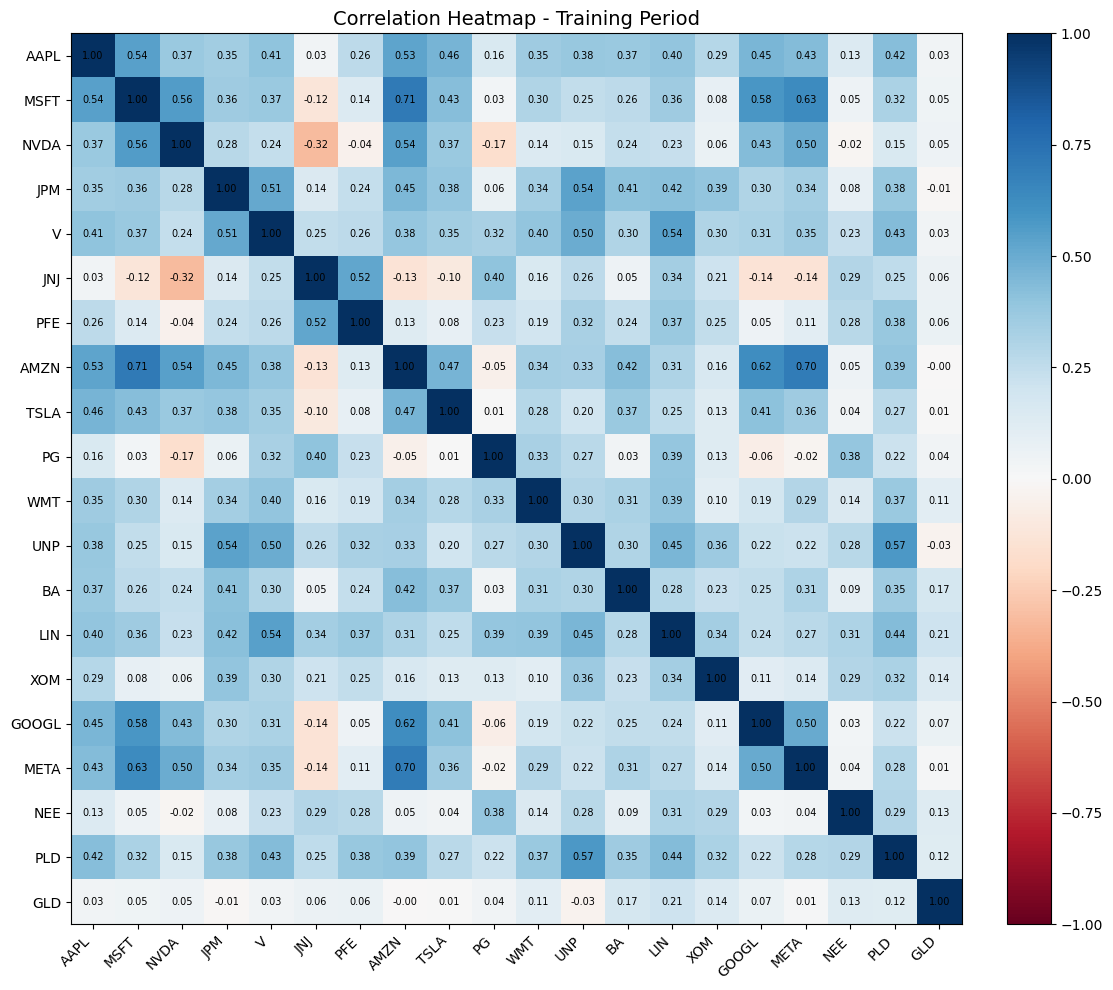

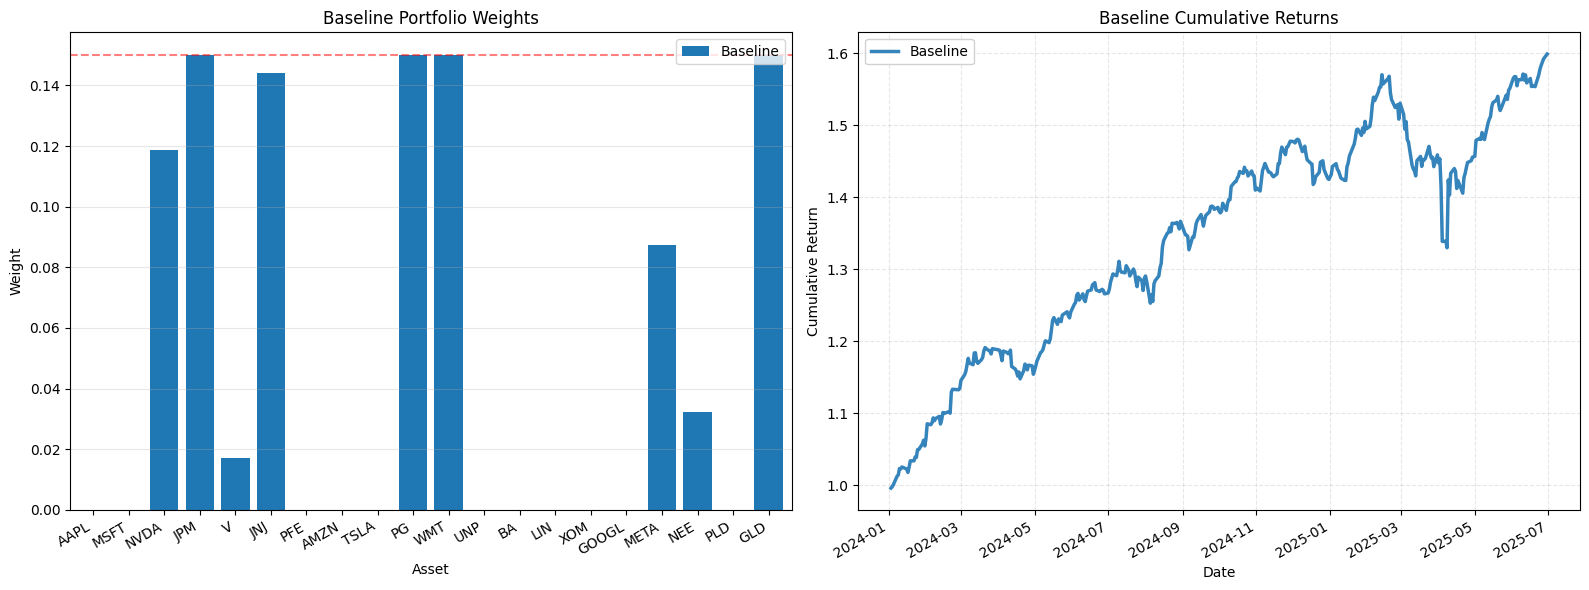

In [4]:
# Step 1: Baseline optimization
mean_returns_train = returns_train.mean() * 252  # Annualized
cov_matrix_train = returns_train.cov() * 252  # Annualized

# Constraints: no short selling, max 15% per asset
bounds_step1 = tuple((0, 0.15) for _ in TICKERS)

weights_baseline = optimize_portfolio(
    mean_returns_train.values,
    cov_matrix_train.values,
    bounds_step1
)

weights_baseline_df = pd.DataFrame({
    'Baseline': weights_baseline
}, index=TICKERS)

print("Baseline portfolio weights (in %):")
weights_baseline_pct = weights_baseline_df * 100
print(weights_baseline_pct.round(2))
print(f"\nSum of weights: {weights_baseline.sum():.6f}")

# Calculate baseline metrics
def calculate_portfolio_metrics(weights, returns, cov_matrix=None):
    """Calculate portfolio performance metrics"""
    w = np.array(weights)
    
    # Portfolio returns
    portfolio_returns = returns @ w
    
    # Annualized metrics
    ann_return = portfolio_returns.mean() * 252
    ann_vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    
    # Maximum drawdown
    cumulative = (1 + portfolio_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Expected Shortfall (CVaR) at 5%
    var_5 = np.percentile(portfolio_returns, 5)
    es_5 = portfolio_returns[portfolio_returns <= var_5].mean()
    
    # Sortino ratio (downside deviation)
    downside_returns = portfolio_returns[portfolio_returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else np.nan
    sortino = ann_return / downside_std if downside_std > 0 else np.nan
    
    return {
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_drawdown,
        'Expected Shortfall (5%)': es_5 * np.sqrt(252),  # Annualized
        'Sortino Ratio': sortino
    }

baseline_metrics = calculate_portfolio_metrics(weights_baseline, returns_train, cov_matrix_train)
print("\nBaseline portfolio metrics (training period):")
for key, value in baseline_metrics.items():
    print(f"{key}: {value:.4f}")

# Visualizations for Step 1
# 1. Correlation heatmap
corr_train = returns_train.corr()
plt.figure(figsize=(12, 10))
im = plt.imshow(corr_train, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_train.columns)), corr_train.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_train.index)), corr_train.index)
for i in range(len(corr_train.index)):
    for j in range(len(corr_train.columns)):
        plt.text(j, i, f"{corr_train.iloc[i, j]:.2f}", ha="center", va="center", 
                color="black", fontsize=7)
plt.title("Correlation Heatmap - Training Period", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap_training.png', dpi=300)
plt.show()

# 2. Baseline weights and cumulative returns (combined)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
weights_baseline_df.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Baseline Portfolio Weights', fontsize=12)
axes[0].set_ylabel('Weight')
axes[0].set_xlabel('Asset')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0.15, color='r', linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.3, axis='y')

baseline_cumulative = (1 + returns_train @ weights_baseline).cumprod()
baseline_cumulative.plot(ax=axes[1], label='Baseline', linewidth=2.5, 
                         color='#1f77b4', alpha=0.9)
axes[1].set_title('Baseline Cumulative Returns', fontsize=12)
axes[1].set_ylabel('Cumulative Return')
axes[1].set_xlabel('Date')
axes[1].legend(framealpha=0.9)
axes[1].grid(alpha=0.3, linestyle='--')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_summary.png', dpi=300)
plt.show()


## Step 2.1: CREM Denoising Implementation

Based on Moen's code snippets (2.2 and 2.4)


Data dimensions: T=373, N=20, q=18.6500

CREM Denoising Results:
Signal factors: 2, Noise factors: 18


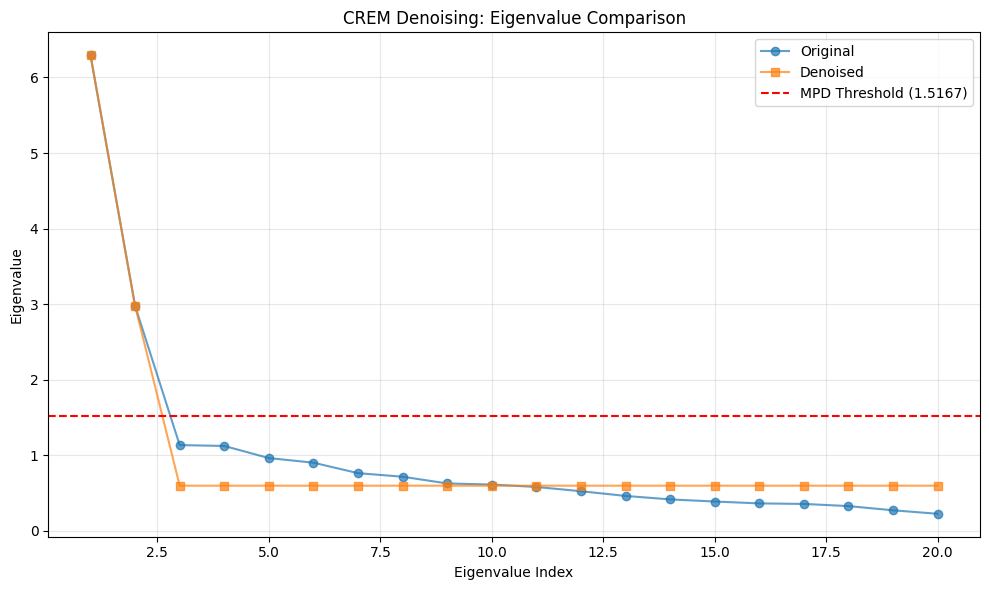

In [5]:
# CREM Denoising Functions (based on Moen's snippets)

def getPCA(corr_matrix):
    """
    Snippet 2.2: Get PCA with eigenvalues in descending order
    Returns eigenvalues and eigenvectors sorted by eigenvalue magnitude
    """
    eigenvals, eigenvecs = np.linalg.eigh(corr_matrix)
    
    # Sort in descending order
    idx = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]
    
    return eigenvals, eigenvecs

def findMaxEval(q, T, N):
    """
    Snippet 2.4: Find maximum eigenvalue expected from random matrix (MPD)
    q = T/N (number of observations / number of assets)
    """
    # Marčenko-Pastur distribution parameters
    # Maximum eigenvalue for random matrix
    lambda_max = (1 + np.sqrt(1/q))**2
    
    return lambda_max

def corr2cov(corr_matrix, std):
    """
    Convert correlation matrix to covariance matrix
    """
    std_matrix = np.diag(std)
    cov_matrix = std_matrix @ corr_matrix @ std_matrix
    return cov_matrix

def deNoiseCov(cov_matrix, q, bwidth=0.01):
    """
    CREM denoising: Constant Residual Eigenvalue Method
    Replaces noisy eigenvalues with their average
    
    Parameters:
    - cov_matrix: empirical covariance matrix
    - q: T/N (number of observations / number of assets)
    - bwidth: bandwidth parameter for KDE (optional, default 0.01)
    """
    # Get standard deviations
    std = np.sqrt(np.diag(cov_matrix))
    
    # Convert to correlation matrix
    std_inv = np.diag(1 / std)
    corr_matrix = std_inv @ cov_matrix @ std_inv
    
    # Get PCA
    eigenvals, eigenvecs = getPCA(corr_matrix)
    
    # Find maximum eigenvalue from MPD
    lambda_max = findMaxEval(q, None, len(eigenvals))
    
    # Determine number of factors (non-random eigenvalues)
    nFacts = np.sum(eigenvals > lambda_max)
    
    # Separate signal and noise eigenvalues
    signal_eigenvals = eigenvals[:nFacts]
    noise_eigenvals = eigenvals[nFacts:]
    
    # Replace noise eigenvalues with their average
    if len(noise_eigenvals) > 0:
        noise_avg = np.mean(noise_eigenvals)
        denoised_eigenvals = np.concatenate([
            signal_eigenvals,
            np.full(len(noise_eigenvals), noise_avg)
        ])
    else:
        denoised_eigenvals = eigenvals
    
    # Reconstruct correlation matrix
    eigenvals_matrix = np.diag(denoised_eigenvals)
    corr_denoised = eigenvecs @ eigenvals_matrix @ eigenvecs.T
    
    # Ensure it's still a valid correlation matrix (symmetric, unit diagonal)
    corr_denoised = (corr_denoised + corr_denoised.T) / 2
    np.fill_diagonal(corr_denoised, 1.0)
    
    # Convert back to covariance matrix
    cov_denoised = corr2cov(corr_denoised, std)
    
    return cov_denoised, nFacts, eigenvals, denoised_eigenvals

# Test CREM denoising
T, N = returns_train.shape
q = T / N

print(f"Data dimensions: T={T}, N={N}, q={q:.4f}")

cov_denoised, nFacts, eigenvals_orig, eigenvals_denoised = deNoiseCov(
    cov_matrix_train.values, q
)

print(f"\nCREM Denoising Results:")
print(f"Signal factors: {nFacts}, Noise factors: {len(eigenvals_orig) - nFacts}")

# Visualize eigenvalue comparison
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvals_orig) + 1), eigenvals_orig, 'o-', label='Original', alpha=0.7)
plt.plot(range(1, len(eigenvals_denoised) + 1), eigenvals_denoised, 's-', label='Denoised', alpha=0.7)
lambda_max = findMaxEval(q, T, N)
plt.axhline(y=lambda_max, color='r', linestyle='--', label=f'MPD Threshold ({lambda_max:.4f})')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('CREM Denoising: Eigenvalue Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'crem_eigenvalues.png', dpi=300)
plt.show()

# Convert back to DataFrame
cov_matrix_denoised = pd.DataFrame(cov_denoised, index=TICKERS, columns=TICKERS)


## Step 2.2: HRP Clustering Implementation

Hierarchical Risk Parity with three stages: Tree Clustering, Quasi-Diagonalization, Recursive Bisection


Computing HRP portfolio...
HRP weights sum: 1.000000

HRP metrics:
Sharpe: 1.1688, Max DD: -0.2596


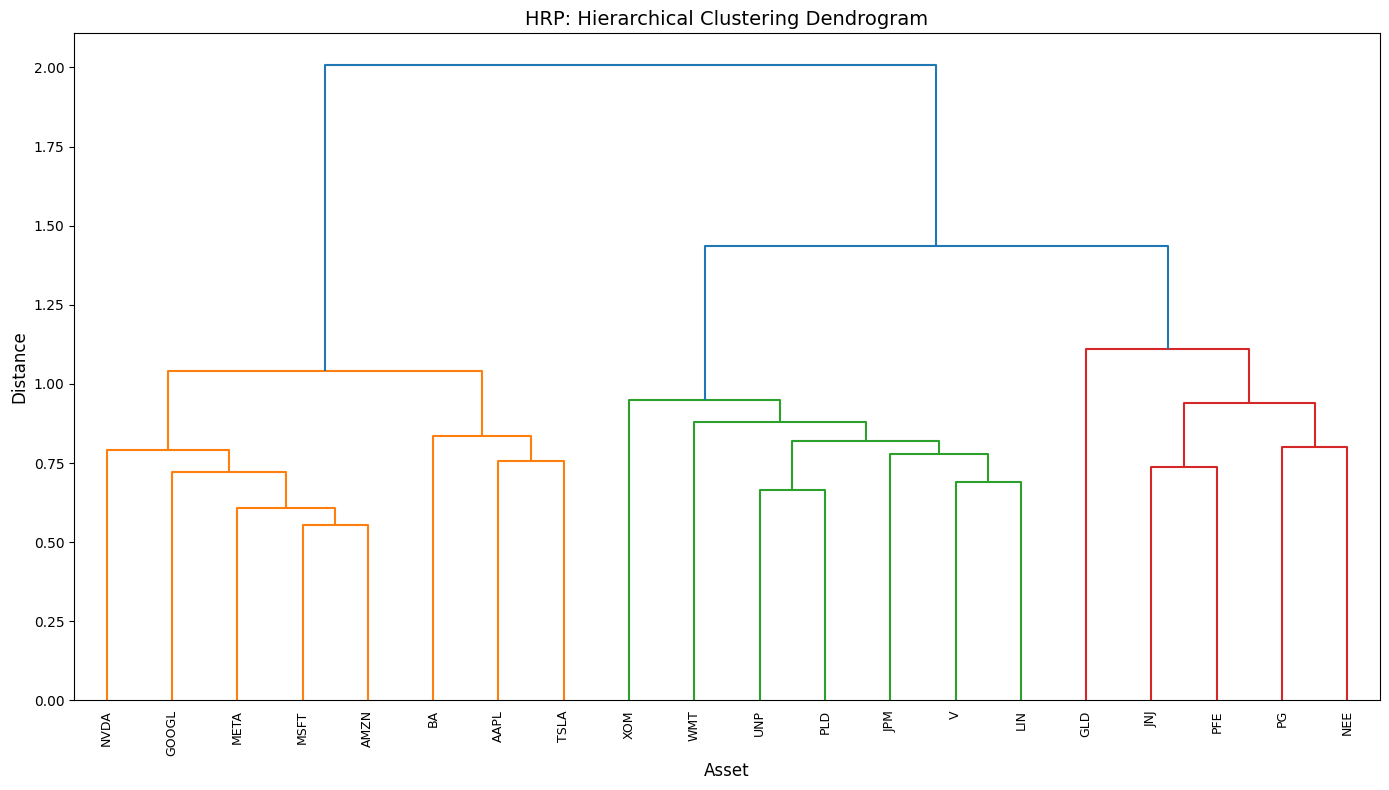

In [6]:
# HRP Implementation

def compute_distance_matrix(corr_matrix):
    """
    Convert correlation matrix to distance matrix
    d_ij = sqrt((1 - rho_ij) / 2)
    """
    distance_matrix = np.sqrt((1 - corr_matrix) / 2)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def compute_euclidean_distance(distance_matrix):
    """
    Compute Euclidean distance between columns of distance matrix
    d_tilde_ij = sqrt(sum_n (d_ni - d_nj)^2)
    """
    n = distance_matrix.shape[0]
    euclidean_dist = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            diff = distance_matrix[:, i] - distance_matrix[:, j]
            euclidean_dist[i, j] = np.sqrt(np.sum(diff**2))
            euclidean_dist[j, i] = euclidean_dist[i, j]
    
    return euclidean_dist

def quasi_diagonalize(linkage_matrix, n_assets):
    """
    Quasi-diagonalization: Reorder assets based on hierarchical clustering
    """
    # Build dendrogram structure
    # linkage_matrix is from scipy.cluster.hierarchy.linkage
    
    # Get the order from dendrogram
    from scipy.cluster.hierarchy import dendrogram
    dn = dendrogram(linkage_matrix, no_plot=True)
    sortIx = dn['leaves']
    
    return sortIx

def recursive_bisection(cov_matrix, indices):
    """
    Recursive bisection: Allocate weights using inverse variance
    
    Parameters:
    - cov_matrix: covariance matrix (DataFrame, already reordered)
    - indices: list of indices [0, 1, 2, ..., n-1] for the reordered matrix
    """
    n = len(indices)
    weights = np.ones(n)
    
    def bisect(items):
        """Recursive bisection function
        items: list of positions in the reordered matrix [0, 1, 2, ...]
        """
        if len(items) == 1:
            return
        
        # Split items into two halves
        n_items = len(items)
        mid = n_items // 2
        left_items = items[:mid]
        right_items = items[mid:]
        
        # Calculate variance for each subset
        # Left subset - use positions directly since cov_matrix is already reordered
        left_cov = cov_matrix.iloc[left_items, left_items].values
        left_std = np.sqrt(np.diag(left_cov))
        # Avoid division by zero
        left_std = np.where(left_std < 1e-8, 1e-8, left_std)
        left_inv_var = 1 / (left_std**2)
        left_weights = left_inv_var / np.sum(left_inv_var)
        left_var = left_weights @ left_cov @ left_weights
        
        # Right subset
        right_cov = cov_matrix.iloc[right_items, right_items].values
        right_std = np.sqrt(np.diag(right_cov))
        right_std = np.where(right_std < 1e-8, 1e-8, right_std)
        right_inv_var = 1 / (right_std**2)
        right_weights = right_inv_var / np.sum(right_inv_var)
        right_var = right_weights @ right_cov @ right_weights
        
        # Calculate split factor (inverse variance weighting)
        # Avoid division by zero
        if left_var < 1e-8 or right_var < 1e-8:
            alpha = 0.5  # Equal split if variance is too small
        else:
            alpha = (1 / right_var) / (1 / left_var + 1 / right_var)
        
        # Update weights
        for i in left_items:
            weights[i] *= alpha
        for i in right_items:
            weights[i] *= (1 - alpha)
        
        # Recursively bisect subsets
        if len(left_items) > 1:
            bisect(left_items)
        if len(right_items) > 1:
            bisect(right_items)
    
    # Start with all indices [0, 1, 2, ..., n-1]
    bisect(list(range(n)))
    
    # Normalize weights
    weights = weights / np.sum(weights)
    
    return weights

def hrp_portfolio(cov_matrix, returns, linkage_method='ward'):
    """
    Hierarchical Risk Parity portfolio construction
    
    Parameters:
    - cov_matrix: covariance matrix (DataFrame)
    - returns: returns data (DataFrame)
    - linkage_method: 'ward', 'single', or 'average'
    """
    # Stage 1: Tree Clustering
    corr_matrix = returns.corr()
    distance_matrix = compute_distance_matrix(corr_matrix.values)
    euclidean_dist = compute_euclidean_distance(distance_matrix)
    
    # Convert to condensed distance matrix for linkage
    condensed_dist = squareform(euclidean_dist)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method=linkage_method)
    
    # Stage 2: Quasi-Diagonalization
    sortIx = quasi_diagonalize(linkage_matrix, len(cov_matrix))
    
    # Stage 3: Recursive Bisection
    # Note: sortIx contains the reordered indices from dendrogram
    # We need to work with a reordered covariance matrix
    cov_reordered = cov_matrix.iloc[sortIx, :].iloc[:, sortIx]
    weights = recursive_bisection(cov_reordered, list(range(len(sortIx))))
    
    # Reorder weights back to match original asset order
    # weights[i] corresponds to asset at position sortIx[i] in original order
    weights_ordered = np.zeros(len(cov_matrix))
    for i, original_idx in enumerate(sortIx):
        weights_ordered[original_idx] = weights[i]
    
    return weights_ordered, linkage_matrix, sortIx

# Test HRP
print("Computing HRP portfolio...")
weights_hrp, linkage_matrix_hrp, sortIx_hrp = hrp_portfolio(
    cov_matrix_train, returns_train, linkage_method='ward'
)

weights_hrp_df = pd.DataFrame({
    'HRP': weights_hrp
}, index=TICKERS)

print(f"HRP weights sum: {weights_hrp.sum():.6f}")

# Calculate HRP metrics
hrp_metrics = calculate_portfolio_metrics(weights_hrp, returns_train, cov_matrix_train)
print("\nHRP metrics:")
print(f"Sharpe: {hrp_metrics['Sharpe Ratio']:.4f}, Max DD: {hrp_metrics['Max Drawdown']:.4f}")

# Visualization: Dendrogram only
plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix_hrp, labels=TICKERS, leaf_rotation=90, leaf_font_size=9)
plt.title('HRP: Hierarchical Clustering Dendrogram', fontsize=14)
plt.xlabel('Asset', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hrp_dendrogram.png', dpi=300)
plt.show()


## Step 2.3: Walk-Forward Backtesting Implementation


Running walk-forward backtest...
Note: Using optimized parameters (purge=1, embargo=1, step_size=5) to improve performance
Walk-forward backtest completed:
Number of rebalancing dates: 115
Date range: 2025-01-14 00:00:00 to 2025-06-30 00:00:00

Walk-forward metrics:
Sharpe: 0.4272, Max DD: -0.1759


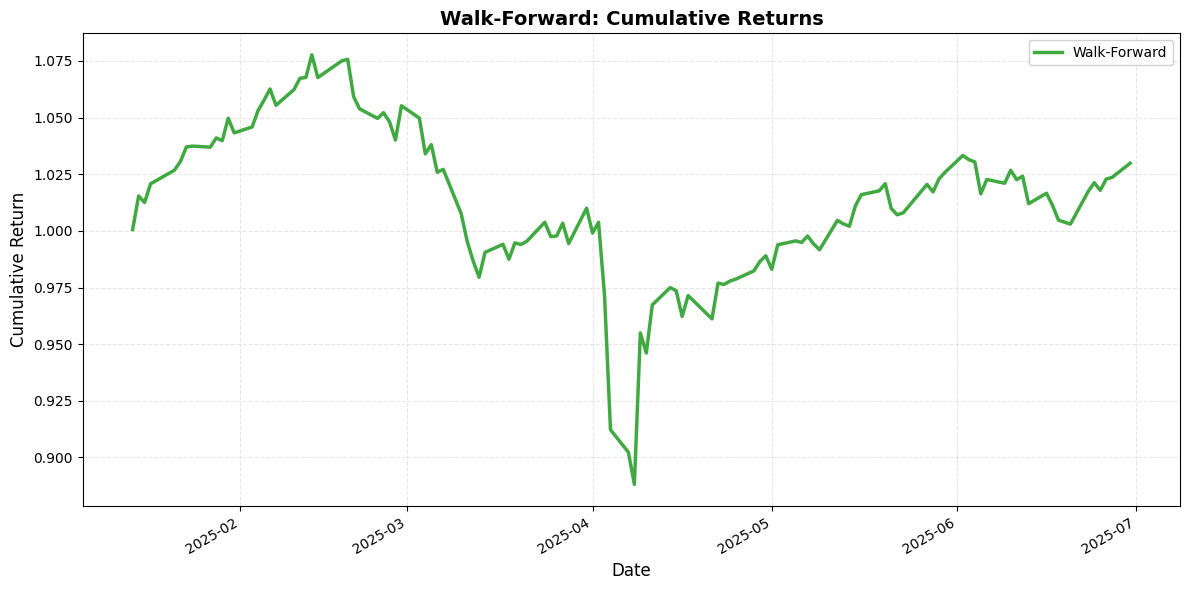

In [7]:
# Improved Walk-Forward Backtesting Framework with Purge and Embargo Periods
# Based on CPCV (Combinatorial Purged Cross-Validation) principles
# Implements purge period (between training and test) and embargo period (after test)
# to avoid look-ahead bias and data leakage

def walk_forward_backtest(returns, optimization_func, window=252, bounds=None, 
                         purge_period=5, embargo_period=5, step_size=1, test_period_length=5):
    """
    Improved walk-forward backtesting with purge and embargo periods
    Based on CPCV principles to avoid look-ahead bias and data leakage
    
    Time structure: [Training Period] → [Purge Period] → [Test Period] → [Embargo Period]
    
    Parameters:
    - returns: DataFrame of asset returns
    - optimization_func: function that takes (mean_returns, cov_matrix, bounds) and returns weights
    - window: training window size (default 252 trading days)
    - bounds: portfolio constraints
    - purge_period: days between training end and test start (default 5, avoids overlap)
    - embargo_period: days after test before next training (default 5, avoids leakage)
    - step_size: days to advance between rebalancing (default 1)
    - test_period_length: number of days in test period (default 5, for more robust evaluation)
    
    Returns:
    - portfolio_returns_series: Series of portfolio returns
    - weights_df: DataFrame of weights over time
    """
    portfolio_returns = []
    weights_history = []
    rebalance_dates = []
    
    n_assets = len(returns.columns)
    
    # Minimum required: window + purge + embargo + test_period_length
    min_required = window + purge_period + embargo_period + test_period_length
    
    # Start from minimum required point
    i = min_required
    
    while i < len(returns):
        # Training period: [i-embargo-purge-window, i-embargo-purge]
        train_end = i - embargo_period - purge_period
        train_start = train_end - window
        
        if train_start < 0:
            i += step_size
            continue
        
        # Get training window (excluding purge and embargo periods)
        est_window = returns.iloc[train_start:train_end]
        
        if len(est_window) < window * 0.8:  # Need at least 80% of window
            i += step_size
            continue
        
        # Calculate statistics
        mean_returns_est = est_window.mean() * 252
        cov_matrix_est = est_window.cov() * 252
        
        # Optimize portfolio
        try:
            # Check if optimization_func accepts window parameter
            import inspect
            sig = inspect.signature(optimization_func)
            if 'window' in sig.parameters:
                weights = optimization_func(mean_returns_est.values, cov_matrix_est.values, bounds, window)
            else:
                weights = optimization_func(mean_returns_est.values, cov_matrix_est.values, bounds)
            
            # Test period: after purge period, test for test_period_length days
            test_start_idx = train_end + purge_period
            test_end_idx = min(test_start_idx + test_period_length, len(returns))
            
            # Collect returns for all test days
            for test_idx in range(test_start_idx, test_end_idx):
                if test_idx < len(returns):
                    test_return = returns.iloc[test_idx]
                    port_return = test_return @ weights
                    portfolio_returns.append(port_return)
                    weights_history.append(weights)
                    rebalance_dates.append(returns.index[test_idx])
            
        except Exception as e:
            print(f"Warning: Optimization failed at {returns.index[i]}: {e}")
            # Use previous weights or equal weights
            if len(weights_history) > 0:
                weights = weights_history[-1]
            else:
                weights = np.ones(n_assets) / n_assets
            
            # Test period: after purge period, test for test_period_length days
            test_start_idx = train_end + purge_period
            test_end_idx = min(test_start_idx + test_period_length, len(returns))
            
            for test_idx in range(test_start_idx, test_end_idx):
                if test_idx < len(returns):
                    test_return = returns.iloc[test_idx]
                    port_return = test_return @ weights
                    portfolio_returns.append(port_return)
                    weights_history.append(weights)
                    rebalance_dates.append(returns.index[test_idx])
        
        # Advance by step_size
        i += step_size
    
    # Convert to Series/DataFrame
    if len(portfolio_returns) > 0:
        portfolio_returns_series = pd.Series(portfolio_returns, index=rebalance_dates)
        weights_df = pd.DataFrame(weights_history, index=rebalance_dates, columns=returns.columns)
    else:
        portfolio_returns_series = pd.Series(dtype=float)
        weights_df = pd.DataFrame(columns=returns.columns)
    
    return portfolio_returns_series, weights_df

# Define optimization function for walk-forward
def optimize_for_backtest(mean_returns, cov_matrix, bounds):
    """Optimization function for walk-forward backtesting"""
    return optimize_portfolio(mean_returns, cov_matrix, bounds)

# Run walk-forward backtest on training data
# Optimized parameters: reduced purge/embargo, increased rebalancing interval
print("Running walk-forward backtest...")
print("Note: Using optimized parameters (purge=1, embargo=1, step_size=5) to improve performance")
bounds_wf = tuple((0, 0.15) for _ in TICKERS)

portfolio_returns_wf, weights_wf = walk_forward_backtest(
    returns_train,
    optimize_for_backtest,
    window=252,
    bounds=bounds_wf,
    purge_period=1,  # Reduced from 5 to 1
    embargo_period=1,  # Reduced from 5 to 1
    step_size=5,  # Rebalance every 5 days instead of daily
    test_period_length=5  # Test for 5 days instead of 1 day for more robust evaluation
)

print(f"Walk-forward backtest completed:")
print(f"Number of rebalancing dates: {len(portfolio_returns_wf)}")
print(f"Date range: {portfolio_returns_wf.index[0]} to {portfolio_returns_wf.index[-1]}")

# Calculate walk-forward metrics
# Note: portfolio_returns_wf is already portfolio returns, not asset returns
# So we need to calculate metrics directly from portfolio returns
wf_returns_series = portfolio_returns_wf

# Calculate metrics from portfolio returns
wf_metrics_dict = calculate_metrics_from_returns(portfolio_returns_wf)

print("\nWalk-forward metrics:")
print(f"Sharpe: {wf_metrics_dict['Sharpe Ratio']:.4f}, Max DD: {wf_metrics_dict['Max Drawdown']:.4f}")

# Visualize walk-forward performance
wf_cumulative = (1 + portfolio_returns_wf).cumprod()
plt.figure(figsize=(12, 6))
wf_cumulative.plot(label='Walk-Forward', linewidth=2.5, color='#2ca02c', alpha=0.9)
plt.title('Walk-Forward: Cumulative Returns', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'walkforward_cumulative.png', dpi=300)
plt.show()


## Step 3: Method Combinations

Apply different combinations of improvements:
1. Denoising + Clustering (HRP with denoised covariance)
2. Denoising + Backtesting (Walk-forward with denoised covariance)
3. Clustering + Backtesting (HRP with walk-forward)
4. All three combined


In [8]:
# ===== Step 3: All Scenarios Implementation =====
# We need to implement ALL scenarios:
# 1. Only Denoising
# 2. Only Clustering (HRP)
# 3. Only Backtesting (Walk-Forward)
# 4. Denoising + Clustering
# 5. Denoising + Backtesting
# 6. Clustering + Backtesting
# 7. All Three Combined

print("=" * 80)
print("IMPLEMENTING ALL SCENARIOS")
print("=" * 80)

# ===== Scenario 1: Only Denoising =====
print("\n[1] Only Denoising: Using denoised covariance with baseline optimization")
weights_denoise_only = optimize_portfolio(
    mean_returns_train.values,
    cov_matrix_denoised.values,
    bounds_step1
)
denoise_only_metrics = calculate_portfolio_metrics(
    weights_denoise_only, returns_train, cov_matrix_denoised
)
print(f"  Sharpe: {denoise_only_metrics['Sharpe Ratio']:.4f}, Max DD: {denoise_only_metrics['Max Drawdown']:.4f}")

# Print final weights
weights_denoise_only_final = apply_weight_constraints(weights_denoise_only, max_weight=0.15)
weights_denoise_only_df = pd.DataFrame({'Only Denoising': weights_denoise_only_final}, index=TICKERS)
print("\n  Final Weights (Only Denoising, in %):")
weights_denoise_only_pct = weights_denoise_only_df * 100
print(weights_denoise_only_pct.round(2).T)
print(f"  Sum: {weights_denoise_only_final.sum():.6f}, Max: {weights_denoise_only_final.max()*100:.2f}%")

# ===== Scenario 2: Only Clustering (HRP) - Already done =====
print("\n[2] Only Clustering (HRP): Already computed")
print(f"  Sharpe: {hrp_metrics['Sharpe Ratio']:.4f}, Max DD: {hrp_metrics['Max Drawdown']:.4f}")

# Print final weights
weights_hrp_final = apply_weight_constraints(weights_hrp, max_weight=0.15)
weights_hrp_final_df = pd.DataFrame({'Only Clustering (HRP)': weights_hrp_final}, index=TICKERS)
print("\n  Final Weights (Only Clustering (HRP), in %):")
weights_hrp_final_pct = weights_hrp_final_df * 100
print(weights_hrp_final_pct.round(2).T)
print(f"  Sum: {weights_hrp_final.sum():.6f}, Max: {weights_hrp_final.max()*100:.2f}%")

# ===== Scenario 3: Only Backtesting (Walk-Forward) - Already done =====
print("\n[3] Only Backtesting (Walk-Forward): Already computed")
print(f"  Sharpe: {wf_metrics_dict['Sharpe Ratio']:.4f}, Max DD: {wf_metrics_dict['Max Drawdown']:.4f}")

# Print final weights (average of last 5 windows)
if len(weights_wf) > 0:
    n_windows = min(5, len(weights_wf))
    wf_final_weights = weights_wf.iloc[-n_windows:].mean(axis=0).values
    wf_final_weights = apply_weight_constraints(wf_final_weights, max_weight=0.15)
    wf_final_weights_df = pd.DataFrame({'Only Backtesting (WF)': wf_final_weights}, index=TICKERS)
    print("\n  Final Weights (Only Backtesting (WF), average of last {} windows, in %):".format(n_windows))
    wf_final_weights_pct = wf_final_weights_df * 100
    print(wf_final_weights_pct.round(2).T)
    print(f"  Sum: {wf_final_weights.sum():.6f}, Max: {wf_final_weights.max()*100:.2f}%")
else:
    print("\n  Final Weights (Only Backtesting (WF)): No weights available")

# ===== Scenario 4: Denoising + Clustering =====
print("\n[4] Denoising + Clustering: HRP with denoised covariance")
weights_denoise_hrp, _, _ = hrp_portfolio(
    cov_matrix_denoised, returns_train, linkage_method='ward'
)
denoise_hrp_metrics = calculate_portfolio_metrics(
    weights_denoise_hrp, returns_train, cov_matrix_denoised
)
print(f"  Sharpe: {denoise_hrp_metrics['Sharpe Ratio']:.4f}, Max DD: {denoise_hrp_metrics['Max Drawdown']:.4f}")

# Print final weights
weights_denoise_hrp_final = apply_weight_constraints(weights_denoise_hrp, max_weight=0.15)
weights_denoise_hrp_final_df = pd.DataFrame({'Denoising + Clustering': weights_denoise_hrp_final}, index=TICKERS)
print("\n  Final Weights (Denoising + Clustering, in %):")
weights_denoise_hrp_final_pct = weights_denoise_hrp_final_df * 100
print(weights_denoise_hrp_final_pct.round(2).T)
print(f"  Sum: {weights_denoise_hrp_final.sum():.6f}, Max: {weights_denoise_hrp_final.max()*100:.2f}%")

# ===== Scenario 5: Denoising + Backtesting =====
print("\n[5] Denoising + Backtesting: Walk-forward with denoised covariance")
def optimize_with_denoised_cov(mean_returns, cov_matrix, bounds, window=252):
    """Optimization function that uses denoised covariance"""
    N_est = len(mean_returns)
    q_est = window / N_est if window > 0 and N_est > 0 else 1.0
    cov_denoised, _, _, _ = deNoiseCov(cov_matrix, q_est)
    return optimize_portfolio(mean_returns, cov_denoised, bounds)

portfolio_returns_denoise_wf, weights_denoise_wf = walk_forward_backtest(
    returns_train, optimize_with_denoised_cov, window=252, bounds=bounds_wf,
    purge_period=1, embargo_period=1, step_size=5, test_period_length=5  # Optimized parameters
)
denoise_wf_metrics_dict = calculate_metrics_from_returns(portfolio_returns_denoise_wf)
print(f"  Sharpe: {denoise_wf_metrics_dict['Sharpe Ratio']:.4f}, Max DD: {denoise_wf_metrics_dict['Max Drawdown']:.4f}")

# Print final weights (average of last 5 windows)
if len(weights_denoise_wf) > 0:
    n_windows = min(5, len(weights_denoise_wf))
    denoise_wf_final_weights = weights_denoise_wf.iloc[-n_windows:].mean(axis=0).values
    denoise_wf_final_weights = apply_weight_constraints(denoise_wf_final_weights, max_weight=0.15)
    denoise_wf_final_weights_df = pd.DataFrame({'Denoising + Backtesting': denoise_wf_final_weights}, index=TICKERS)
    print("\n  Final Weights (Denoising + Backtesting, average of last {} windows, in %):".format(n_windows))
    denoise_wf_final_weights_pct = denoise_wf_final_weights_df * 100
    print(denoise_wf_final_weights_pct.round(2).T)
    print(f"  Sum: {denoise_wf_final_weights.sum():.6f}, Max: {denoise_wf_final_weights.max()*100:.2f}%")
else:
    print("\n  Final Weights (Denoising + Backtesting): No weights available")

# ===== Scenario 6: Clustering + Backtesting =====
print("\n[6] Clustering + Backtesting: Walk-forward with HRP at each step")
def walk_forward_hrp(returns, window=252, bounds=None, purge_period=1, embargo_period=1, step_size=5, test_period_length=5):
    """Walk-forward with HRP recomputation at each step"""
    portfolio_returns = []
    weights_history = []
    rebalance_dates = []
    
    # Minimum required: window + purge + embargo + test_period_length
    min_required = window + purge_period + embargo_period + test_period_length
    i = min_required
    
    # Check if we have enough data
    if len(returns) < min_required:
        print(f"Warning: Not enough data for walk_forward_hrp")
        print(f"  Required: {min_required} days, Available: {len(returns)} days")
        return pd.Series(dtype=float), pd.DataFrame(columns=returns.columns)
    
    loop_count = 0
    successful_loops = 0
    exception_count = 0
    skipped_train_start = 0
    skipped_est_window = 0
    
    while i < len(returns):
        loop_count += 1
        
        # Training period: [i-embargo-purge-window, i-embargo-purge]
        train_end = i - embargo_period - purge_period
        train_start = train_end - window
        
        if train_start < 0:
            skipped_train_start += 1
            i += step_size
            continue
        
        est_window = returns.iloc[train_start:train_end]
        est_window_len = len(est_window)
        min_est_window_len = window * 0.8
        
        if est_window_len < min_est_window_len:
            skipped_est_window += 1
            i += step_size
            continue
        
        cov_matrix_est = est_window.cov() * 252
        
        try:
            # HRP needs DataFrame inputs
            # Use est_window.columns instead of TICKERS to ensure alignment
            tickers_actual = est_window.columns.tolist()
            cov_df = pd.DataFrame(cov_matrix_est.values, index=tickers_actual, columns=tickers_actual)
            returns_df = est_window  # Already a DataFrame
            
            weights, _, _ = hrp_portfolio(cov_df, returns_df, linkage_method='ward')
            
            # Apply 15% constraint to HRP weights (HRP doesn't enforce this by itself)
            weights = apply_weight_constraints(weights, max_weight=0.15)
            
            # Convert to numpy array for consistent handling
            if isinstance(weights, pd.Series):
                weights = weights.values
            
            # Test period: after purge period (i - embargo_period)
            # Test period: after purge period (train_end + purge_period)
            # Test period: after purge period, test for test_period_length days
            test_start_idx = train_end + purge_period
            test_end_idx = min(test_start_idx + test_period_length, len(returns))
            
            # Collect returns for all test days
            test_days_collected = 0
            for test_idx in range(test_start_idx, test_end_idx):
                if test_idx < len(returns) and test_idx >= 0:
                    test_return = returns.iloc[test_idx]
                    # Ensure weights and returns are aligned
                    if isinstance(weights, np.ndarray):
                        weights = pd.Series(weights, index=returns.columns)
                    # Align test_return and weights by index
                    aligned_weights = weights.reindex(test_return.index, fill_value=0)
                    port_return = (test_return * aligned_weights).sum()
                    portfolio_returns.append(port_return)
                    weights_history.append(weights)
                    rebalance_dates.append(returns.index[test_idx])
                    test_days_collected += 1
        except Exception as e:
            if len(weights_history) > 0:
                weights = weights_history[-1]
            else:
                weights = np.ones(len(returns.columns)) / len(returns.columns)
            
            # Test period: after purge period (i - embargo_period)
            # Test period: after purge period (train_end + purge_period)
            # Test period: after purge period, test for test_period_length days
            test_start_idx = train_end + purge_period
            test_end_idx = min(test_start_idx + test_period_length, len(returns))
            
                        # Collect returns for all test days
            for test_idx in range(test_start_idx, test_end_idx):
                if test_idx < len(returns) and test_idx >= 0:
                    test_return = returns.iloc[test_idx]
                    # Ensure weights and returns are aligned
                    if isinstance(weights, np.ndarray):
                        weights = pd.Series(weights, index=returns.columns)
                    # Align test_return and weights by index
                    aligned_weights = weights.reindex(test_return.index, fill_value=0)
                    port_return = (test_return * aligned_weights).sum()
                    portfolio_returns.append(port_return)
                    weights_history.append(weights)
                    rebalance_dates.append(returns.index[test_idx])
        
        # Advance by step_size
        i += step_size
    
    # Convert to Series and DataFrame
    if len(portfolio_returns) == 0:
        portfolio_returns_series = pd.Series(dtype=float)
        weights_df = pd.DataFrame(columns=returns.columns)
    else:
        portfolio_returns_series = pd.Series(portfolio_returns, index=rebalance_dates)
        weights_df = pd.DataFrame(weights_history, index=rebalance_dates, columns=returns.columns)
    return portfolio_returns_series, weights_df

# Adjust window size to ensure we have enough valid loops
# With 373 days of data, using window=180 gives us more room for walk-forward
portfolio_returns_hrp_wf, weights_hrp_wf = walk_forward_hrp(
    returns_train, window=180, bounds=bounds_wf,  # Reduced from 252 to 180
    purge_period=1, embargo_period=1, step_size=5, test_period_length=5  # Optimized parameters
)

# Check if results are empty
if len(portfolio_returns_hrp_wf) == 0:
    print(f"Warning: walk_forward_hrp returned empty results!")
    print(f"  returns_train length: {len(returns_train)}")
    # Use actual parameters passed to the function
    actual_window = 180
    actual_min_required = actual_window + 1 + 1 + 5  # window + purge + embargo + test_period_length
    print(f"  min_required: {actual_min_required} (window={actual_window} + purge=1 + embargo=1 + test_period=5)")
    print(f"  This means we need at least {actual_min_required} days of data")
    print(f"  Available data: {len(returns_train)} days")
    if len(returns_train) < actual_min_required:
        print(f"  ERROR: Not enough data! Need {actual_min_required - len(returns_train)} more days")
    else:
        print(f"  Data should be sufficient, but no results collected")

hrp_wf_metrics_dict = calculate_metrics_from_returns(portfolio_returns_hrp_wf)
print(f"  Sharpe: {hrp_wf_metrics_dict['Sharpe Ratio']:.4f}, Max DD: {hrp_wf_metrics_dict['Max Drawdown']:.4f}")

# Print final weights (average of last 5 windows)
if len(weights_hrp_wf) > 0:
    n_windows = min(5, len(weights_hrp_wf))
    hrp_wf_final_weights = weights_hrp_wf.iloc[-n_windows:].mean(axis=0).values
    hrp_wf_final_weights = apply_weight_constraints(hrp_wf_final_weights, max_weight=0.15)
    hrp_wf_final_weights_df = pd.DataFrame({'Clustering + Backtesting': hrp_wf_final_weights}, index=TICKERS)
    print("\n  Final Weights (Clustering + Backtesting, average of last {} windows, in %):".format(n_windows))
    hrp_wf_final_weights_pct = hrp_wf_final_weights_df * 100
    print(hrp_wf_final_weights_pct.round(2).T)
    print(f"  Sum: {hrp_wf_final_weights.sum():.6f}, Max: {hrp_wf_final_weights.max()*100:.2f}%")
else:
    print("\n  Final Weights (Clustering + Backtesting): No weights available")

# ===== Scenario 7: All Three Combined =====
print("\n[7] All Three Combined: Walk-forward with denoised HRP at each step")
def walk_forward_all_three(returns, window=252, bounds=None, purge_period=1, embargo_period=1, step_size=5, test_period_length=5):
    """Walk-forward with denoised HRP at each step"""
    portfolio_returns = []
    weights_history = []
    rebalance_dates = []
    
    # Minimum required: window + purge + embargo + test_period_length
    min_required = window + purge_period + embargo_period + test_period_length
    i = min_required
    
    loop_count = 0
    successful_loops = 0
    exception_count = 0
    
    while i < len(returns):
        loop_count += 1
        # Training period: [i-embargo-purge-window, i-embargo-purge]
        # Training period: [i-embargo-purge-window, i-embargo-purge]
        train_end = i - embargo_period - purge_period
        train_start = train_end - window
        
        if train_start < 0:
            i += step_size
            continue
        
        est_window = returns.iloc[train_start:train_end]
        est_window_len = len(est_window)
        min_est_window_len = window * 0.8
        
        if est_window_len < min_est_window_len:
            i += step_size
            continue
        
        cov_matrix_est = est_window.cov() * 252
        
        try:
            # First denoise
            N_est = len(est_window.columns)
            q_est = window / N_est if window > 0 and N_est > 0 else 1.0
            cov_denoised, _, _, _ = deNoiseCov(cov_matrix_est.values, q_est)
            
            # Then apply HRP
            cov_df = pd.DataFrame(cov_denoised, index=TICKERS, columns=TICKERS)
            returns_df = est_window  # Already a DataFrame
            weights, _, _ = hrp_portfolio(cov_df, returns_df, linkage_method='ward')
            
            # Test period: after purge period (i - embargo_period)
            # Test period: after purge period (train_end + purge_period)
            # Test period: after purge period, test for test_period_length days
            test_start_idx = train_end + purge_period
            test_end_idx = min(test_start_idx + test_period_length, len(returns))
            
            # Collect returns for all test days
            test_days_collected = 0
            for test_idx in range(test_start_idx, test_end_idx):
                if test_idx < len(returns) and test_idx >= 0:
                    test_return = returns.iloc[test_idx]
                    # Ensure weights and returns are aligned
                    if isinstance(weights, np.ndarray):
                        weights = pd.Series(weights, index=returns.columns)
                    # Align test_return and weights by index
                    aligned_weights = weights.reindex(test_return.index, fill_value=0)
                    port_return = (test_return * aligned_weights).sum()
                    portfolio_returns.append(port_return)
                    weights_history.append(weights)
                    rebalance_dates.append(returns.index[test_idx])
                    test_days_collected += 1
            
            if test_days_collected > 0:
                successful_loops += 1
        except Exception as e:
            exception_count += 1
            if len(weights_history) > 0:
                weights = weights_history[-1]
            else:
                weights = np.ones(len(returns.columns)) / len(returns.columns)
            
            # Test period: after purge period, test for test_period_length days
            test_start_idx = train_end + purge_period
            test_end_idx = min(test_start_idx + test_period_length, len(returns))
            
            # Collect returns for all test days
            for test_idx in range(test_start_idx, test_end_idx):
                if test_idx < len(returns) and test_idx >= 0:
                    test_return = returns.iloc[test_idx]
                    # Ensure weights and returns are aligned
                    if isinstance(weights, np.ndarray):
                        weights = pd.Series(weights, index=returns.columns)
                    # Align test_return and weights by index
                    aligned_weights = weights.reindex(test_return.index, fill_value=0)
                    port_return = (test_return * aligned_weights).sum()
                    portfolio_returns.append(port_return)
                    weights_history.append(weights)
                    rebalance_dates.append(returns.index[test_idx])
        
        # Advance by step_size
        i += step_size
    
    
    # Convert to Series and DataFrame
    if len(portfolio_returns) == 0:
        print(f"Warning: walk_forward_hrp completed {loop_count} loops but collected 0 returns")
        print(f"  Successful loops: {successful_loops}, Exceptions: {exception_count}")
        print(f"  Skipped (train_start < 0): {skipped_train_start}, Skipped (est_window < 80%): {skipped_est_window}")
        if loop_count == 0:
            print(f"  Loop never executed! Initial i={min_required}, len(returns)={len(returns)}")
            print(f"  Condition check: {min_required} < {len(returns)} = {min_required < len(returns)}")
        elif successful_loops == 0 and exception_count == 0:
            print(f"  All loops were skipped due to conditions")
            print(f"  Final i={i}, total skipped={skipped_train_start + skipped_est_window}")
        portfolio_returns_series = pd.Series(dtype=float)
        weights_df = pd.DataFrame(columns=returns.columns)
    else:
        portfolio_returns_series = pd.Series(portfolio_returns, index=rebalance_dates)
        weights_df = pd.DataFrame(weights_history, index=rebalance_dates, columns=returns.columns)
    
    return portfolio_returns_series, weights_df

# Adjust window size to ensure we have enough valid loops
portfolio_returns_all_three, weights_all_three = walk_forward_all_three(
    returns_train, window=180, bounds=bounds_wf,  # Reduced from 252 to 180
    purge_period=1, embargo_period=1, step_size=5, test_period_length=5  # Optimized parameters
)

all_three_metrics_dict = calculate_metrics_from_returns(portfolio_returns_all_three)
print(f"  Sharpe: {all_three_metrics_dict['Sharpe Ratio']:.4f}, Max DD: {all_three_metrics_dict['Max Drawdown']:.4f}")

# Print final weights (average of last 5 windows)
if len(weights_all_three) > 0:
    n_windows = min(5, len(weights_all_three))
    all_three_final_weights = weights_all_three.iloc[-n_windows:].mean(axis=0).values
    all_three_final_weights = apply_weight_constraints(all_three_final_weights, max_weight=0.15)
    all_three_final_weights_df = pd.DataFrame({'All Three Combined': all_three_final_weights}, index=TICKERS)
    print("\n  Final Weights (All Three Combined, average of last {} windows, in %):".format(n_windows))
    all_three_final_weights_pct = all_three_final_weights_df * 100
    print(all_three_final_weights_pct.round(2).T)
    print(f"  Sum: {all_three_final_weights.sum():.6f}, Max: {all_three_final_weights.max()*100:.2f}%")
else:
    print("\n  Final Weights (All Three Combined): No weights available")

print("\n" + "=" * 80)
print("ALL SCENARIOS COMPLETED!")
print("=" * 80)

# Store all results for comparison (all 7 scenarios + baseline)
all_results = {
    'Baseline': {
        'weights': weights_baseline,
        'metrics': baseline_metrics
    },
    'Only Denoising': {
        'weights': weights_denoise_only,
        'metrics': denoise_only_metrics
    },
    'Only Clustering (HRP)': {
        'weights': weights_hrp,
        'metrics': hrp_metrics
    },
    'Only Backtesting (WF)': {
        'weights': (weights_wf.iloc[-min(5, len(weights_wf)):].mean(axis=0).values 
                   if len(weights_wf) > 0 else weights_baseline),
        'metrics': wf_metrics_dict
    },
    'Denoising + Clustering': {
        'weights': weights_denoise_hrp,
        'metrics': denoise_hrp_metrics
    },
    'Denoising + Backtesting': {
        'weights': (weights_denoise_wf.iloc[-min(5, len(weights_denoise_wf)):].mean(axis=0).values 
                   if len(weights_denoise_wf) > 0 else weights_baseline),
        'metrics': denoise_wf_metrics_dict
    },
    'Clustering + Backtesting': {
        'weights': (weights_hrp_wf.iloc[-min(5, len(weights_hrp_wf)):].mean(axis=0).values 
                   if len(weights_hrp_wf) > 0 else weights_baseline),
        'metrics': hrp_wf_metrics_dict
    },
    'All Three Combined': {
        'weights': (weights_all_three.iloc[-min(5, len(weights_all_three)):].mean(axis=0).values 
                   if len(weights_all_three) > 0 else weights_baseline),
        'metrics': all_three_metrics_dict
    }
}

print("\nAll scenarios stored for comparison!")


IMPLEMENTING ALL SCENARIOS

[1] Only Denoising: Using denoised covariance with baseline optimization
  Sharpe: 2.4223, Max DD: -0.1570

  Final Weights (Only Denoising, in %):
                AAPL  MSFT   NVDA   JPM     V  JNJ  PFE  AMZN  TSLA    PG  \
Only Denoising   0.0   0.0  11.34  15.0  6.15  9.4  0.0   0.0   0.0  15.0   

                 WMT  UNP   BA  LIN  XOM  GOOGL  META   NEE  PLD   GLD  
Only Denoising  15.0  0.0  0.0  0.0  0.0    0.0  9.16  3.95  0.0  15.0  
  Sum: 1.000000, Max: 15.00%

[2] Only Clustering (HRP): Already computed
  Sharpe: 1.1688, Max DD: -0.2596

  Final Weights (Only Clustering (HRP), in %):
                       AAPL  MSFT   NVDA  JPM     V   JNJ   PFE  AMZN  TSLA  \
Only Clustering (HRP)  6.68  2.09  16.15  5.5  1.34  2.26  4.41   3.8   6.4   

                         PG   WMT   UNP     BA   LIN   XOM  GOOGL   META  \
Only Clustering (HRP)  0.64  0.18  4.89  11.07  0.97  0.19   7.27  14.39   

                        NEE   PLD   GLD  
Only Clusteri

## Step 4: Performance Comparison

Compare all methods using multiple metrics


In [9]:
# ===== Output All Training Weights =====
print("=" * 80)
print("ALL METHODS: TRAINING PERIOD PORTFOLIO WEIGHTS")
print("=" * 80)

# Create a comprehensive DataFrame with all weights
all_weights_data = {
    'Baseline': weights_baseline,
    'Only Denoising': weights_denoise_only,
    'Only Clustering (HRP)': weights_hrp,
    'Denoising + Clustering': weights_denoise_hrp
}

# Add Walk-Forward weights (use average of last 5 windows)
if len(weights_wf) > 0:
    n_windows = min(5, len(weights_wf))
    wf_avg_weights = weights_wf.iloc[-n_windows:].mean(axis=0).values
    wf_avg_weights = np.clip(wf_avg_weights, 0, 0.15)
    wf_avg_weights = wf_avg_weights / wf_avg_weights.sum()
    all_weights_data['Only Backtesting (WF)'] = wf_avg_weights
else:
    all_weights_data['Only Backtesting (WF)'] = weights_baseline  # Fallback

if len(weights_denoise_wf) > 0:
    n_windows = min(5, len(weights_denoise_wf))
    denoise_wf_avg_weights = weights_denoise_wf.iloc[-n_windows:].mean(axis=0).values
    denoise_wf_avg_weights = np.clip(denoise_wf_avg_weights, 0, 0.15)
    denoise_wf_avg_weights = denoise_wf_avg_weights / denoise_wf_avg_weights.sum()
    all_weights_data['Denoising + Backtesting'] = denoise_wf_avg_weights
else:
    all_weights_data['Denoising + Backtesting'] = weights_baseline  # Fallback

if len(weights_hrp_wf) > 0:
    n_windows = min(5, len(weights_hrp_wf))
    hrp_wf_avg_weights = weights_hrp_wf.iloc[-n_windows:].mean(axis=0).values
    hrp_wf_avg_weights = np.clip(hrp_wf_avg_weights, 0, 0.15)
    hrp_wf_avg_weights = hrp_wf_avg_weights / hrp_wf_avg_weights.sum()
    all_weights_data['Clustering + Backtesting'] = hrp_wf_avg_weights
else:
    all_weights_data['Clustering + Backtesting'] = weights_baseline  # Fallback

if len(weights_all_three) > 0:
    n_windows = min(5, len(weights_all_three))
    all_three_avg_weights = weights_all_three.iloc[-n_windows:].mean(axis=0).values
    all_three_avg_weights = np.clip(all_three_avg_weights, 0, 0.15)
    all_three_avg_weights = all_three_avg_weights / all_three_avg_weights.sum()
    all_weights_data['All Three Combined'] = all_three_avg_weights
else:
    all_weights_data['All Three Combined'] = weights_baseline  # Fallback

# Ensure all weights satisfy 15% constraint before creating DataFrame
print("\n" + "=" * 80)
print("Applying 15% constraint to all weights...")
print("=" * 80)
for method in all_weights_data.keys():
    weights = all_weights_data[method]
    if isinstance(weights, pd.Series):
        weights = weights.values
    max_weight_before = np.max(weights)
    weights = apply_weight_constraints(weights, max_weight=0.15)
    max_weight_after = np.max(weights)
    if max_weight_before > 0.15:
        print(f"  {method:30s}: Max weight {max_weight_before*100:.2f}% -> {max_weight_after*100:.2f}% (adjusted)")
    all_weights_data[method] = weights

# Create DataFrame
all_weights_df = pd.DataFrame(all_weights_data, index=TICKERS)

# Display the weights table
print("\nPortfolio Weights (Training Period, in %):")
print("=" * 80)
all_weights_pct = all_weights_df * 100
print(all_weights_pct.round(2))

# Verify no weight exceeds 15%
print("\n" + "=" * 80)
print("Weight Constraint Verification (Max should be <= 15%):")
print("=" * 80)
for method in all_weights_df.columns:
    max_weight = all_weights_df[method].max()
    if max_weight > 0.15:
        print(f"  WARNING: {method:30s}: Max weight = {max_weight*100:.2f}% (exceeds 15%)")
    else:
        print(f"  PASS:    {method:30s}: Max weight = {max_weight*100:.2f}%")

# Verify weights sum to 1
print("\n" + "=" * 80)
print("Weights Sum Verification:")
print("=" * 80)
for method in all_weights_df.columns:
    weight_sum = all_weights_df[method].sum()
    print(f"{method:30s}: {weight_sum:.6f}")

# Save to CSV
all_weights_df.to_csv(OUTPUT_DIR / 'all_methods_training_weights.csv')
print(f"\n Weights saved to: {OUTPUT_DIR / 'all_methods_training_weights.csv'}")

# Display top 5 holdings for each method
print("\n" + "=" * 80)
print("Top 5 Holdings for Each Method:")
print("=" * 80)
for method in all_weights_df.columns:
    top5 = all_weights_df[method].nlargest(5)
    print(f"\n{method}:")
    for asset, weight in top5.items():
        print(f"  {asset:10s}: {weight:.4f} ({weight*100:.2f}%)")

# Summary statistics
print("\n" + "=" * 80)
print("Weight Distribution Statistics:")
print("=" * 80)
weight_stats = pd.DataFrame({
    'Mean': all_weights_df.mean(axis=0),
    'Std': all_weights_df.std(axis=0),
    'Min': all_weights_df.min(axis=0),
    'Max': all_weights_df.max(axis=0),
    'Non-Zero Count': (all_weights_df > 0.001).sum(axis=0)
})
print(weight_stats.round(4))


ALL METHODS: TRAINING PERIOD PORTFOLIO WEIGHTS

Applying 15% constraint to all weights...
  Only Clustering (HRP)         : Max weight 22.14% -> 16.15% (adjusted)
  Denoising + Clustering        : Max weight 22.30% -> 16.18% (adjusted)

Portfolio Weights (Training Period, in %):
       Baseline  Only Denoising  Only Clustering (HRP)  \
AAPL       0.00            0.00                   6.68   
MSFT       0.00            0.00                   2.09   
NVDA      11.87           11.34                  16.15   
JPM       15.00           15.00                   5.50   
V          1.72            6.15                   1.34   
JNJ       14.42            9.40                   2.26   
PFE        0.00            0.00                   4.41   
AMZN       0.00            0.00                   3.80   
TSLA       0.00            0.00                   6.40   
PG        15.00           15.00                   0.64   
WMT       15.00           15.00                   0.18   
UNP        0.00         

Performance Comparison (Training Period):
                          Annual Return  Annual Volatility  Sharpe Ratio  \
Method                                                                     
Baseline                         0.3261             0.1343        2.4289   
Only Denoising                   0.3345             0.1381        2.4223   
Only Clustering (HRP)            0.2908             0.2488        1.1688   
Only Backtesting (WF)            0.0832             0.1948        0.4272   
Denoising + Clustering           0.2877             0.2498        1.1519   
Denoising + Backtesting          0.0801             0.1928        0.4152   
Clustering + Backtesting         0.1178             0.2582        0.4564   
All Three Combined               0.1371             0.2671        0.5136   

                          Sortino Ratio  Max Drawdown  Expected Shortfall (5%)  
Method                                                                          
Baseline                         3.

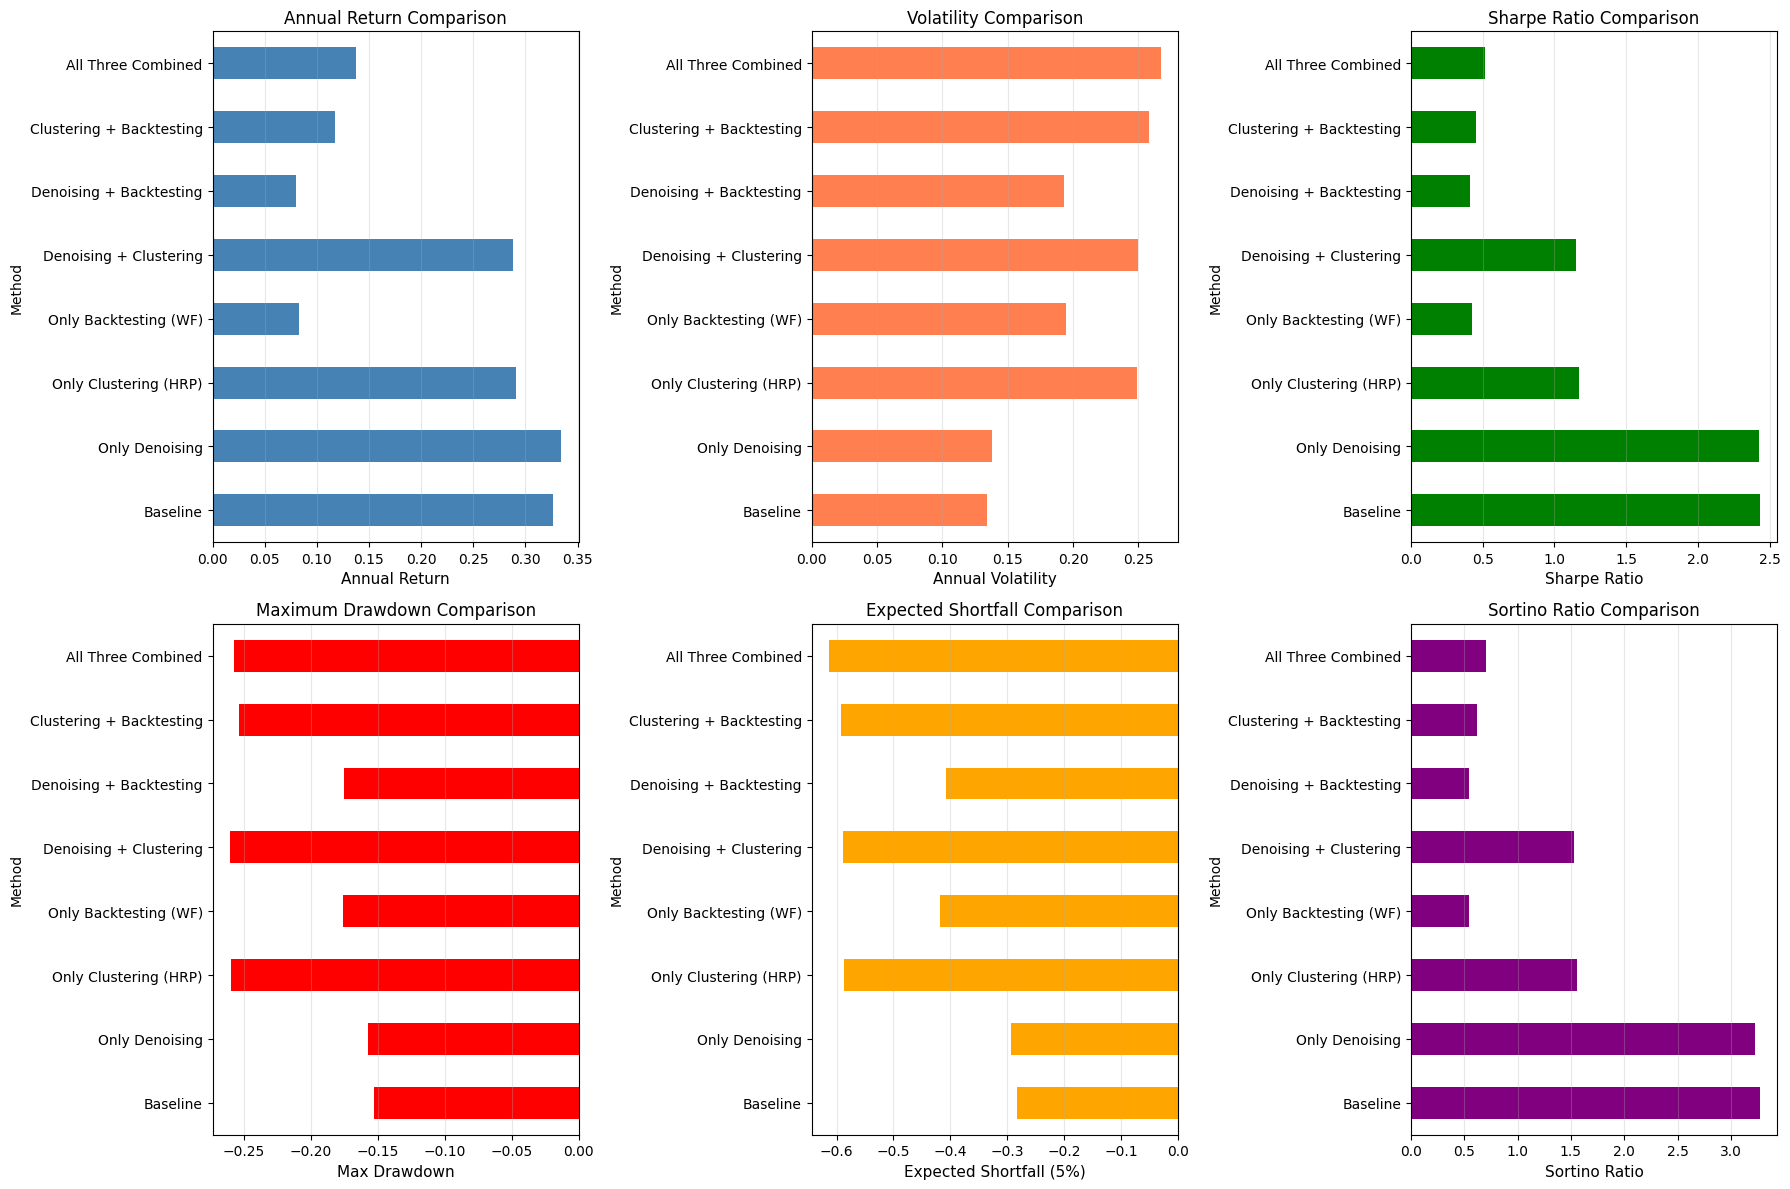

Baseline: min=0.9963, max=1.5986, mean=1.3439
Only Denoising: min=0.9959, max=1.6174, mean=1.3517
Only Clustering: min=0.9869, max=1.4804, mean=1.2712
Denoising+Clustering: min=0.9866, max=1.4744, mean=1.2658
Only Backtesting: min=0.8881, max=1.0777, mean=1.0124
Denoising+Backtesting: min=0.8889, max=1.0772, mean=1.0130
Clustering+Backtesting: min=0.8547, max=1.1454, mean=1.0368
All Three Combined: min=0.8631, max=1.1621, mean=1.0489
Y-axis range: [0.7403, 1.7318]


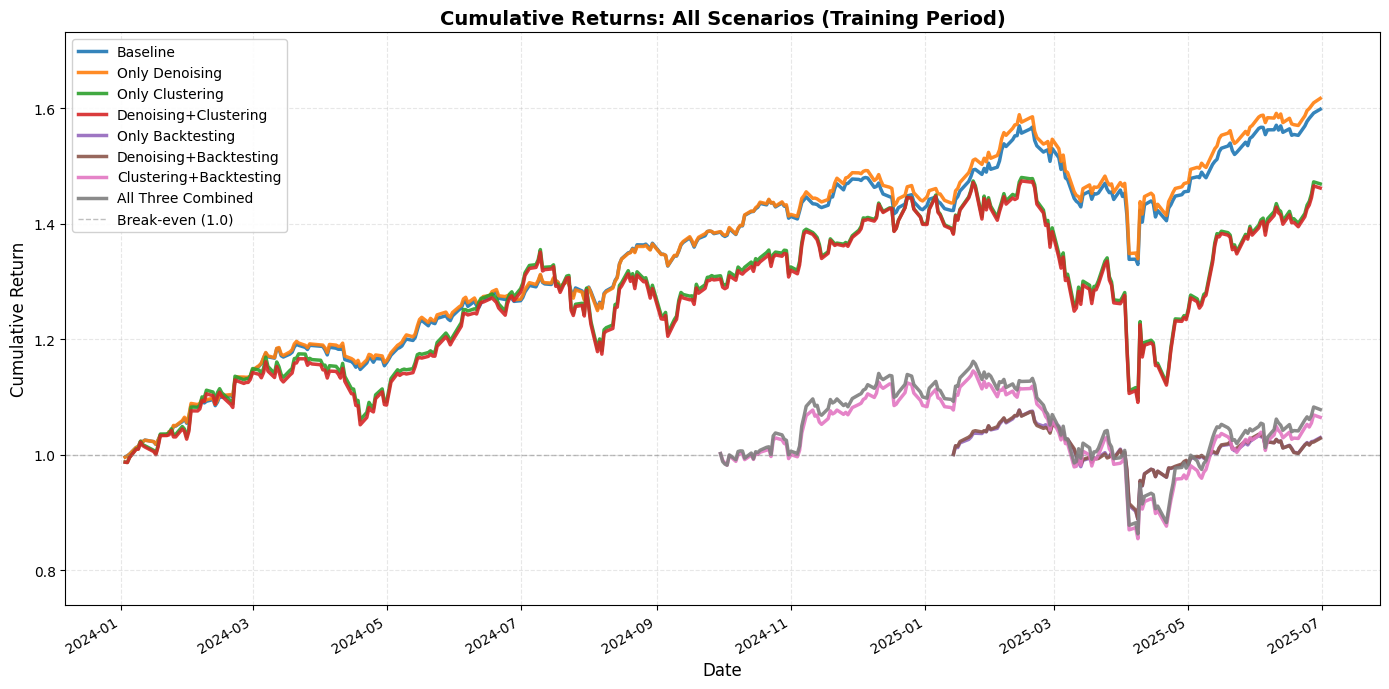

In [10]:
# Performance Comparison

# Create comparison DataFrame
comparison_data = []
for method_name, method_data in all_results.items():
    metrics = method_data['metrics']
    row = {'Method': method_name}
    row.update(metrics)
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Method')

# Select key metrics for comparison
key_metrics = ['Annual Return', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Expected Shortfall (5%)']

comparison_key = comparison_df[key_metrics]
print("Performance Comparison (Training Period):")
print("=" * 80)
print(comparison_key.round(4))

# Save comparison table
comparison_key.to_csv(OUTPUT_DIR / 'performance_comparison_training.csv')

# Identify best method for each metric
print("\n" + "=" * 80)
print("Best Method for Each Metric:")
print("=" * 80)
for metric in key_metrics:
    if metric in comparison_df.columns:
        if 'Drawdown' in metric or 'Shortfall' in metric:
            # Lower is better
            best_method = comparison_df[metric].idxmin()
            best_value = comparison_df[metric].min()
        else:
            # Higher is better
            best_method = comparison_df[metric].idxmax()
            best_value = comparison_df[metric].max()
        print(f"{metric}: {best_method} ({best_value:.4f})")

# Additional comprehensive comparison chart
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Annual Return
ax = axes[0, 0]
returns_vals = comparison_df['Annual Return'].dropna()
returns_vals.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Annual Return', fontsize=11)
ax.set_title('Annual Return Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 2. Annual Volatility
ax = axes[0, 1]
vols_vals = comparison_df['Annual Volatility'].dropna()
vols_vals.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Annual Volatility', fontsize=11)
ax.set_title('Volatility Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 3. Sharpe Ratio
ax = axes[0, 2]
sharpe_vals = comparison_df['Sharpe Ratio'].dropna()
sharpe_vals.plot(kind='barh', ax=ax, color='green')
ax.set_xlabel('Sharpe Ratio', fontsize=11)
ax.set_title('Sharpe Ratio Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 4. Max Drawdown
ax = axes[1, 0]
dd_vals = comparison_df['Max Drawdown'].dropna()
dd_vals.plot(kind='barh', ax=ax, color='red')
ax.set_xlabel('Max Drawdown', fontsize=11)
ax.set_title('Maximum Drawdown Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 5. Expected Shortfall
ax = axes[1, 1]
es_vals = comparison_df['Expected Shortfall (5%)'].dropna()
es_vals.plot(kind='barh', ax=ax, color='orange')
ax.set_xlabel('Expected Shortfall (5%)', fontsize=11)
ax.set_title('Expected Shortfall Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 6. Sortino Ratio
ax = axes[1, 2]
sortino_vals = comparison_df['Sortino Ratio'].dropna()
sortino_vals.plot(kind='barh', ax=ax, color='purple')
ax.set_xlabel('Sortino Ratio', fontsize=11)
ax.set_title('Sortino Ratio Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comprehensive_metrics_comparison.png', dpi=300)
plt.show()

# Cumulative returns comparison for all methods (training period)
returns_dict = {
    'Baseline': returns_train @ weights_baseline,
    'Only Denoising': returns_train @ weights_denoise_only,
    'Only Clustering': returns_train @ weights_hrp,
    'Denoising+Clustering': returns_train @ weights_denoise_hrp
}

# Align walk-forward returns
# Note: Walk-forward needs window (252 days) for estimation, so first 252 days have no returns
# We use NaN instead of 0, so the chart will skip these dates
def align_wf_returns(wf_returns, train_index):
    aligned = pd.Series(index=train_index, dtype=float)
    common_dates = aligned.index.intersection(wf_returns.index)
    if len(common_dates) > 0:
        aligned.loc[common_dates] = wf_returns.loc[common_dates]
        # Don't fillna with 0 - keep NaN so chart starts from first valid date
    return aligned

if len(portfolio_returns_wf) > 0:
    returns_dict['Only Backtesting'] = align_wf_returns(portfolio_returns_wf, returns_train.index)
if len(portfolio_returns_denoise_wf) > 0:
    returns_dict['Denoising+Backtesting'] = align_wf_returns(portfolio_returns_denoise_wf, returns_train.index)
if len(portfolio_returns_hrp_wf) > 0:
    returns_dict['Clustering+Backtesting'] = align_wf_returns(portfolio_returns_hrp_wf, returns_train.index)
if len(portfolio_returns_all_three) > 0:
    returns_dict['All Three Combined'] = align_wf_returns(portfolio_returns_all_three, returns_train.index)

plot_cumulative_returns(
    returns_dict,
    'Cumulative Returns: All Scenarios (Training Period)',
    OUTPUT_DIR / 'cumulative_returns_all_scenarios_training.png'
)


## Step 5: Out-of-Sample Testing

Test all methods on the test period (July 2025)


OUT-OF-SAMPLE TESTING (July 2025) - ALL SCENARIOS
  Using average of last 5 windows for OOS testing
  Using average of last 5 windows for OOS testing
  Using average of last 5 windows for OOS testing
  Using average of last 5 windows for OOS testing

Out-of-Sample Weight Constraint Verification:
  PASS:    Baseline                      : Max weight = 15.00%
  PASS:    Only Denoising                : Max weight = 15.00%
           Adjusted: 22.14% -> 16.15%
           Adjusted: 22.30% -> 16.18%
  PASS:    Only Backtesting (WF)         : Max weight = 15.00%
  PASS:    Denoising + Backtesting       : Max weight = 15.00%
  PASS:    Clustering + Backtesting      : Max weight = 14.15%
  PASS:    All Three Combined            : Max weight = 14.10%

Out-of-Sample Performance Comparison:
                          Annual Return  Annual Volatility  Sharpe Ratio  \
Method                                                                     
Baseline                         0.2368             0.0724

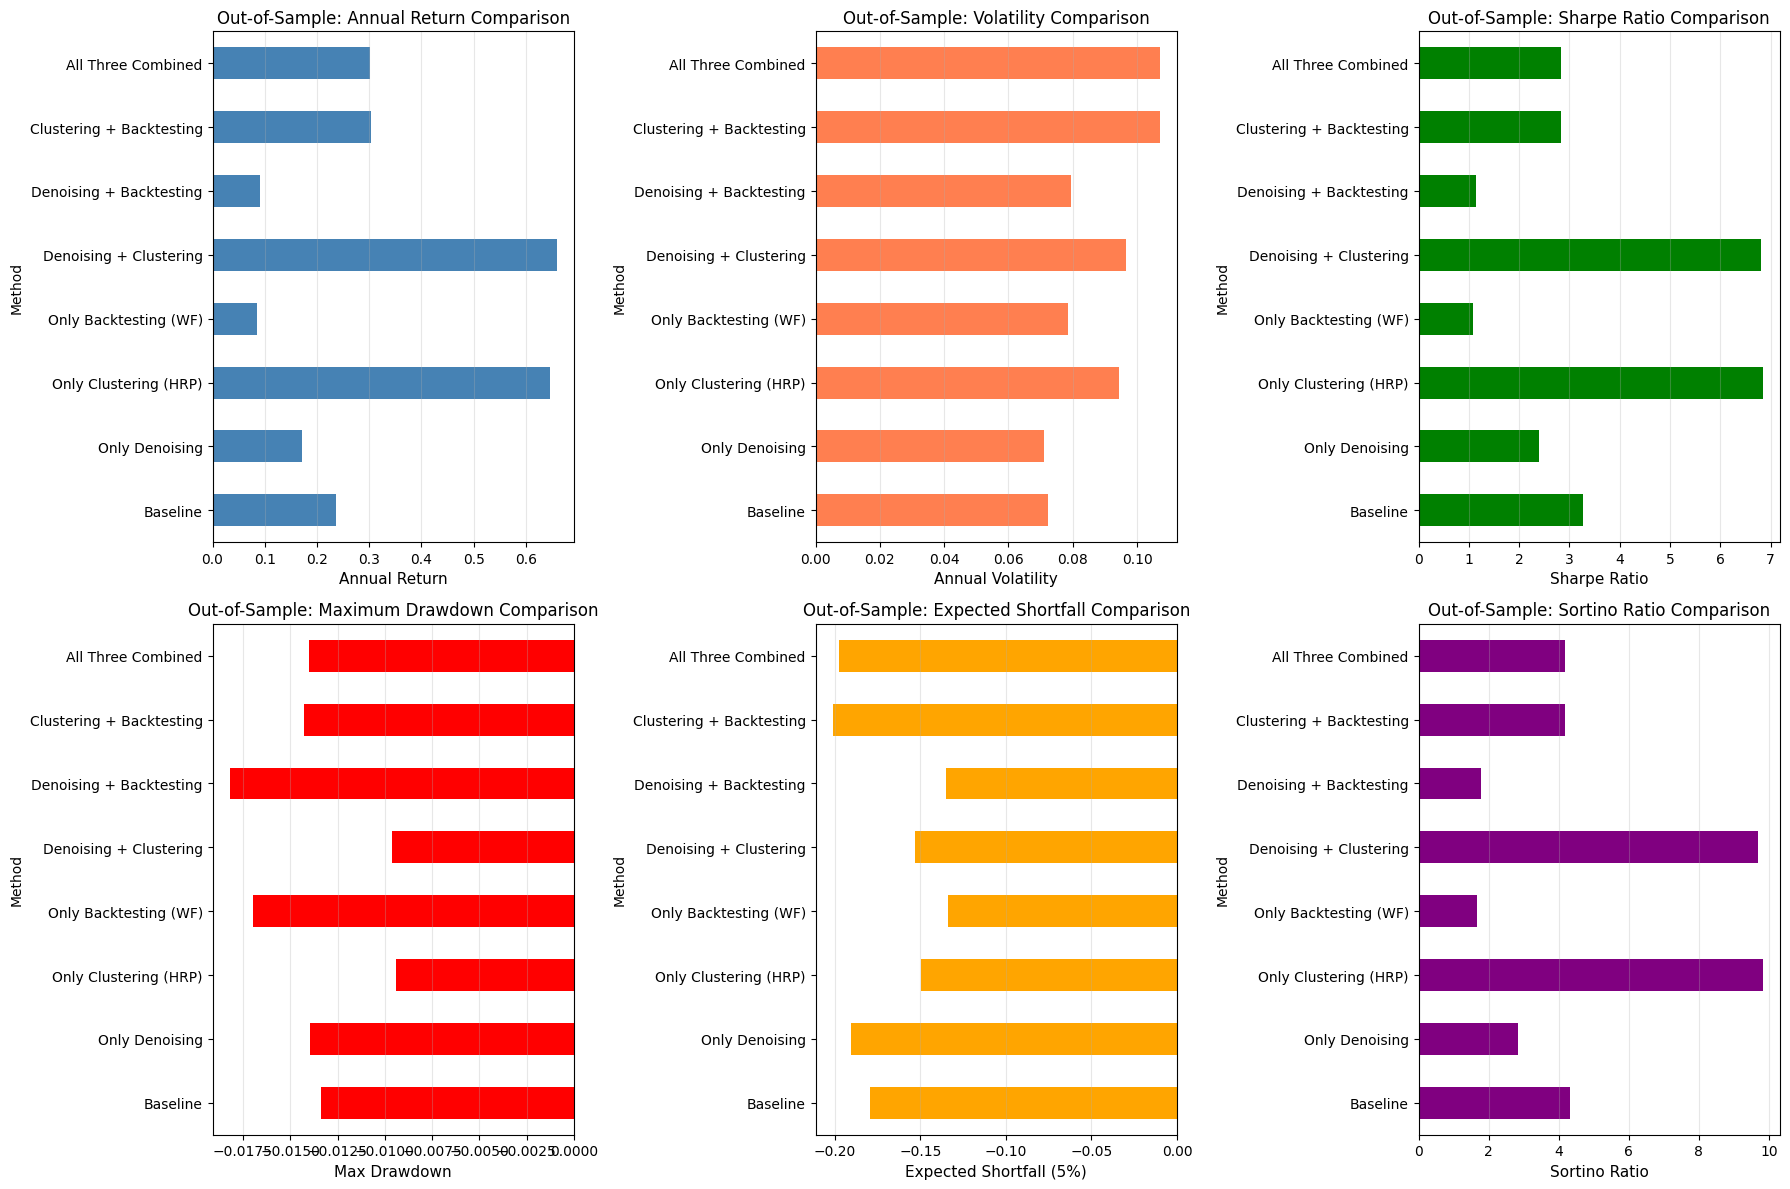

Baseline: min=0.9949, max=1.0274, mean=1.0110
Only Denoising: min=0.9946, max=1.0221, mean=1.0083
Only Clustering: min=1.0122, max=1.0612, mean=1.0381
Denoising+Clustering: min=1.0121, max=1.0623, mean=1.0389
Only Backtesting: min=0.9907, max=1.0154, mean=1.0043
Denoising+Backtesting: min=0.9896, max=1.0159, mean=1.0040
Clustering+Backtesting: min=1.0045, max=1.0370, mean=1.0211
All Three Combined: min=1.0049, max=1.0374, mean=1.0214
Y-axis range: [0.8896, 1.1623]


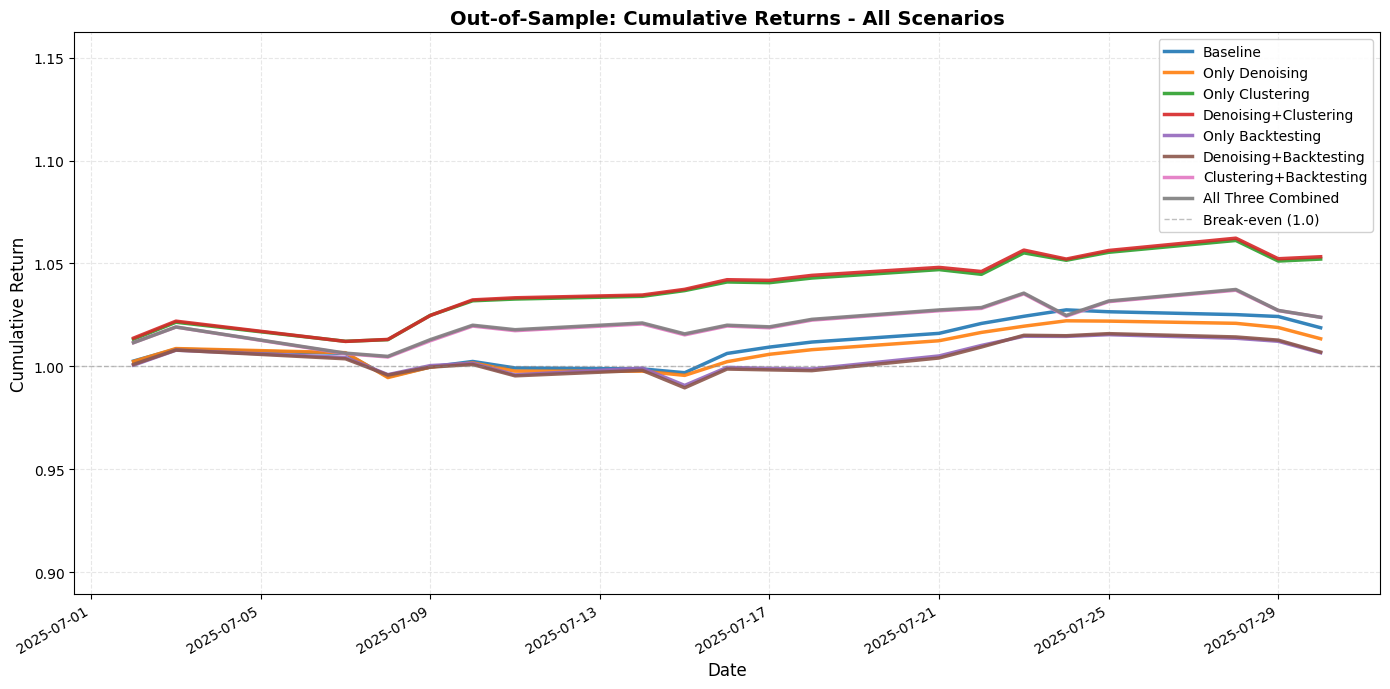


Out-of-sample testing completed!
Test period: 2025-07-02 00:00:00 to 2025-07-30 00:00:00
Number of test days: 20


<Figure size 1200x600 with 0 Axes>

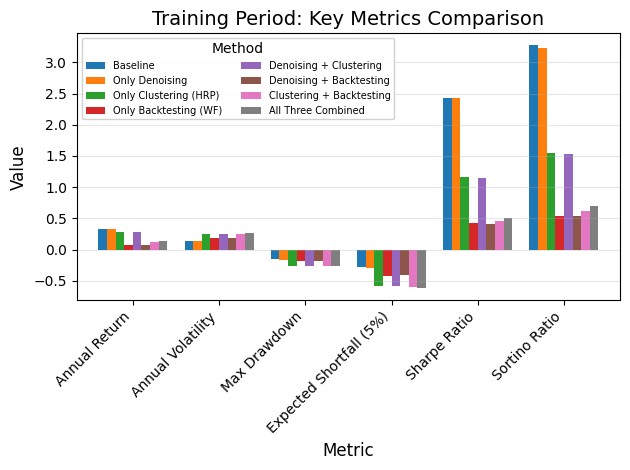

<Figure size 1200x600 with 0 Axes>

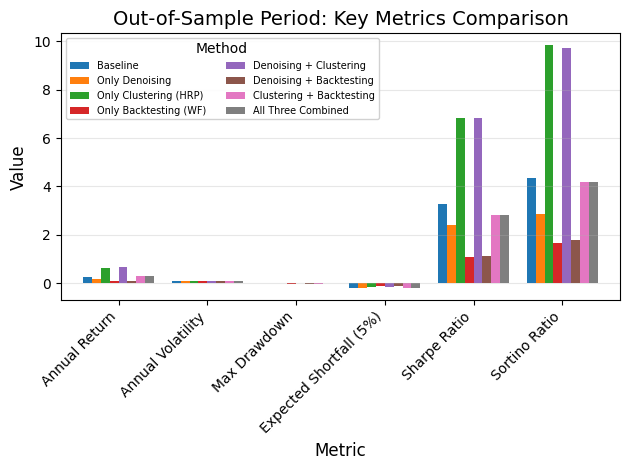

In [11]:
# Out-of-Sample Testing - All Scenarios

print("=" * 80)
print("OUT-OF-SAMPLE TESTING (July 2025) - ALL SCENARIOS")
print("=" * 80)

# Calculate out-of-sample metrics for all scenarios
oos_results = {}

# 1. Baseline
baseline_oos_returns = returns_test @ weights_baseline
baseline_oos_metrics = calculate_portfolio_metrics(weights_baseline, returns_test)
oos_results['Baseline'] = baseline_oos_metrics

# 2. Only Denoising
denoise_only_oos_returns = returns_test @ weights_denoise_only
denoise_only_oos_metrics = calculate_portfolio_metrics(weights_denoise_only, returns_test)
oos_results['Only Denoising'] = denoise_only_oos_metrics

# 3. Only Clustering (HRP)
hrp_oos_returns = returns_test @ weights_hrp
hrp_oos_metrics = calculate_portfolio_metrics(weights_hrp, returns_test)
oos_results['Only Clustering (HRP)'] = hrp_oos_metrics

# 4. Only Backtesting (Walk-Forward)
# Optimized: Use average of last N windows instead of just the last one
if len(weights_wf) > 0:
    # Use average of last 5 windows (or all if less than 5)
    n_windows = min(5, len(weights_wf))
    recent_weights = weights_wf.iloc[-n_windows:].values
    wf_oos_weights = recent_weights.mean(axis=0)
    # Ensure weights sum to 1 and satisfy constraints
    wf_oos_weights = np.clip(wf_oos_weights, 0, 0.15)
    wf_oos_weights = wf_oos_weights / wf_oos_weights.sum()
    
    wf_oos_returns = returns_test @ wf_oos_weights
    wf_oos_metrics = calculate_portfolio_metrics(wf_oos_weights, returns_test)
    oos_results['Only Backtesting (WF)'] = wf_oos_metrics
    print(f"  Using average of last {n_windows} windows for OOS testing")
else:
    oos_results['Only Backtesting (WF)'] = baseline_oos_metrics

# 5. Denoising + Clustering
denoise_hrp_oos_returns = returns_test @ weights_denoise_hrp
denoise_hrp_oos_metrics = calculate_portfolio_metrics(weights_denoise_hrp, returns_test)
oos_results['Denoising + Clustering'] = denoise_hrp_oos_metrics

# 6. Denoising + Backtesting
# Optimized: Use average of last N windows
if len(weights_denoise_wf) > 0:
    n_windows = min(5, len(weights_denoise_wf))
    recent_weights = weights_denoise_wf.iloc[-n_windows:].values
    denoise_wf_oos_weights = recent_weights.mean(axis=0)
    denoise_wf_oos_weights = np.clip(denoise_wf_oos_weights, 0, 0.15)
    denoise_wf_oos_weights = denoise_wf_oos_weights / denoise_wf_oos_weights.sum()
    
    denoise_wf_oos_returns = returns_test @ denoise_wf_oos_weights
    denoise_wf_oos_metrics = calculate_portfolio_metrics(denoise_wf_oos_weights, returns_test)
    oos_results['Denoising + Backtesting'] = denoise_wf_oos_metrics
    print(f"  Using average of last {n_windows} windows for OOS testing")
else:
    oos_results['Denoising + Backtesting'] = baseline_oos_metrics

# 7. Clustering + Backtesting
# Optimized: Use average of last N windows
if len(weights_hrp_wf) > 0:
    n_windows = min(5, len(weights_hrp_wf))
    recent_weights = weights_hrp_wf.iloc[-n_windows:].values
    hrp_wf_oos_weights = recent_weights.mean(axis=0)
    hrp_wf_oos_weights = np.clip(hrp_wf_oos_weights, 0, 0.15)
    hrp_wf_oos_weights = hrp_wf_oos_weights / hrp_wf_oos_weights.sum()
    
    hrp_wf_oos_returns = returns_test @ hrp_wf_oos_weights
    hrp_wf_oos_metrics = calculate_portfolio_metrics(hrp_wf_oos_weights, returns_test)
    oos_results['Clustering + Backtesting'] = hrp_wf_oos_metrics
    print(f"  Using average of last {n_windows} windows for OOS testing")
else:
    oos_results['Clustering + Backtesting'] = baseline_oos_metrics

# 8. All Three Combined
# Optimized: Use average of last N windows
if len(weights_all_three) > 0:
    n_windows = min(5, len(weights_all_three))
    recent_weights = weights_all_three.iloc[-n_windows:].values
    all_three_oos_weights = recent_weights.mean(axis=0)
    all_three_oos_weights = np.clip(all_three_oos_weights, 0, 0.15)
    all_three_oos_weights = all_three_oos_weights / all_three_oos_weights.sum()
    
    all_three_oos_returns = returns_test @ all_three_oos_weights
    all_three_oos_metrics = calculate_portfolio_metrics(all_three_oos_weights, returns_test)
    oos_results['All Three Combined'] = all_three_oos_metrics
    print(f"  Using average of last {n_windows} windows for OOS testing")
else:
    oos_results['All Three Combined'] = baseline_oos_metrics

# Verify all OOS weights satisfy 15% constraint
print("\n" + "=" * 80)
print("Out-of-Sample Weight Constraint Verification:")
print("=" * 80)
oos_weights_dict = {
    'Baseline': weights_baseline,
    'Only Denoising': weights_denoise_only,
    'Only Clustering (HRP)': weights_hrp,
    'Denoising + Clustering': weights_denoise_hrp
}
if len(weights_wf) > 0:
    n_windows = min(5, len(weights_wf))
    wf_oos_weights = weights_wf.iloc[-n_windows:].mean(axis=0).values
    wf_oos_weights = np.clip(wf_oos_weights, 0, 0.15)
    wf_oos_weights = wf_oos_weights / wf_oos_weights.sum()
    oos_weights_dict['Only Backtesting (WF)'] = wf_oos_weights
if len(weights_denoise_wf) > 0:
    n_windows = min(5, len(weights_denoise_wf))
    denoise_wf_oos_weights = weights_denoise_wf.iloc[-n_windows:].mean(axis=0).values
    denoise_wf_oos_weights = np.clip(denoise_wf_oos_weights, 0, 0.15)
    denoise_wf_oos_weights = denoise_wf_oos_weights / denoise_wf_oos_weights.sum()
    oos_weights_dict['Denoising + Backtesting'] = denoise_wf_oos_weights
if len(weights_hrp_wf) > 0:
    n_windows = min(5, len(weights_hrp_wf))
    hrp_wf_oos_weights = weights_hrp_wf.iloc[-n_windows:].mean(axis=0).values
    hrp_wf_oos_weights = np.clip(hrp_wf_oos_weights, 0, 0.15)
    hrp_wf_oos_weights = hrp_wf_oos_weights / hrp_wf_oos_weights.sum()
    oos_weights_dict['Clustering + Backtesting'] = hrp_wf_oos_weights
if len(weights_all_three) > 0:
    n_windows = min(5, len(weights_all_three))
    all_three_oos_weights = weights_all_three.iloc[-n_windows:].mean(axis=0).values
    all_three_oos_weights = np.clip(all_three_oos_weights, 0, 0.15)
    all_three_oos_weights = all_three_oos_weights / all_three_oos_weights.sum()
    oos_weights_dict['All Three Combined'] = all_three_oos_weights

for method, weights in oos_weights_dict.items():
    if isinstance(weights, pd.Series):
        weights = weights.values
    max_weight = np.max(weights)
    if max_weight > 0.15:
        print(f"  WARNING: {method:30s}: Max weight = {max_weight*100:.2f}% (exceeds 15%)")
        # Apply constraint
        weights = apply_weight_constraints(weights, max_weight=0.15)
        max_weight_after = np.max(weights)
        print(f"           Adjusted: {max_weight*100:.2f}% -> {max_weight_after*100:.2f}%")
    else:
        print(f"  PASS:    {method:30s}: Max weight = {max_weight*100:.2f}%")

# Create comparison DataFrame for OOS
oos_comparison_data = []
for method_name, metrics in oos_results.items():
    row = {'Method': method_name}
    row.update(metrics)
    oos_comparison_data.append(row)

oos_comparison_df = pd.DataFrame(oos_comparison_data)
oos_comparison_df = oos_comparison_df.set_index('Method')

# Select key metrics
oos_key_metrics = ['Annual Return', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Expected Shortfall (5%)']
oos_comparison_key = oos_comparison_df[oos_key_metrics]

print("\nOut-of-Sample Performance Comparison:")
print("=" * 80)
print(oos_comparison_key.round(4))

# Save OOS comparison
oos_comparison_key.to_csv(OUTPUT_DIR / 'performance_comparison_oos.csv')

# Compare training vs OOS
print("\n" + "=" * 80)
print("Training vs Out-of-Sample Comparison (Sharpe Ratio):")
print("=" * 80)
training_sharpe = comparison_df['Sharpe Ratio']
oos_sharpe = oos_comparison_df['Sharpe Ratio']

comparison_sharpe = pd.DataFrame({
    'Training': training_sharpe,
    'Out-of-Sample': oos_sharpe
})
comparison_sharpe['Difference'] = comparison_sharpe['Out-of-Sample'] - comparison_sharpe['Training']
print(comparison_sharpe.round(4))

# Visualize OOS performance - Comprehensive comparison chart (2x3)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Annual Return
ax = axes[0, 0]
returns_vals = oos_comparison_df['Annual Return'].dropna()
returns_vals.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Annual Return', fontsize=11)
ax.set_title('Out-of-Sample: Annual Return Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 2. Annual Volatility
ax = axes[0, 1]
vols_vals = oos_comparison_df['Annual Volatility'].dropna()
vols_vals.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Annual Volatility', fontsize=11)
ax.set_title('Out-of-Sample: Volatility Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 3. Sharpe Ratio
ax = axes[0, 2]
sharpe_vals = oos_comparison_df['Sharpe Ratio'].dropna()
sharpe_vals.plot(kind='barh', ax=ax, color='green')
ax.set_xlabel('Sharpe Ratio', fontsize=11)
ax.set_title('Out-of-Sample: Sharpe Ratio Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 4. Max Drawdown
ax = axes[1, 0]
dd_vals = oos_comparison_df['Max Drawdown'].dropna()
dd_vals.plot(kind='barh', ax=ax, color='red')
ax.set_xlabel('Max Drawdown', fontsize=11)
ax.set_title('Out-of-Sample: Maximum Drawdown Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 5. Expected Shortfall
ax = axes[1, 1]
es_vals = oos_comparison_df['Expected Shortfall (5%)'].dropna()
es_vals.plot(kind='barh', ax=ax, color='orange')
ax.set_xlabel('Expected Shortfall (5%)', fontsize=11)
ax.set_title('Out-of-Sample: Expected Shortfall Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# 6. Sortino Ratio
ax = axes[1, 2]
sortino_vals = oos_comparison_df['Sortino Ratio'].dropna()
sortino_vals.plot(kind='barh', ax=ax, color='purple')
ax.set_xlabel('Sortino Ratio', fontsize=11)
ax.set_title('Out-of-Sample: Sortino Ratio Comparison', fontsize=12)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oos_comprehensive_metrics_comparison.png', dpi=300)
plt.show()

# Cumulative returns comparison (OOS) - All scenarios
oos_returns_dict = {
    'Baseline': baseline_oos_returns,
    'Only Denoising': denoise_only_oos_returns,
    'Only Clustering': hrp_oos_returns,
    'Denoising+Clustering': denoise_hrp_oos_returns
}
if len(weights_wf) > 0:
    oos_returns_dict['Only Backtesting'] = wf_oos_returns
if len(weights_denoise_wf) > 0:
    oos_returns_dict['Denoising+Backtesting'] = denoise_wf_oos_returns
if len(weights_hrp_wf) > 0:
    oos_returns_dict['Clustering+Backtesting'] = hrp_wf_oos_returns
if len(weights_all_three) > 0:
    oos_returns_dict['All Three Combined'] = all_three_oos_returns

plot_cumulative_returns(
    oos_returns_dict,
    'Out-of-Sample: Cumulative Returns - All Scenarios',
    OUTPUT_DIR / 'oos_cumulative_returns_all_scenarios.png'
)

print("\nOut-of-sample testing completed!")
print(f"Test period: {returns_test.index[0]} to {returns_test.index[-1]}")
print(f"Number of test days: {len(returns_test)}")

# Final summary visualization: Training vs OOS performance
# Split into two separate figures

# Figure 1: Training period metrics
plt.figure(figsize=(12, 6))
training_metrics_plot = comparison_key[['Annual Return', 'Annual Volatility', 'Max Drawdown', 'Expected Shortfall (5%)', 'Sharpe Ratio', 'Sortino Ratio']].T
training_metrics_plot.plot(kind='bar', width=0.8)
plt.title('Training Period: Key Metrics Comparison', fontsize=14)
plt.ylabel('Value', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.legend(title='Method', fontsize=7, loc='upper left', ncol=2, framealpha=0.9)
plt.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_period_key_metrics.png', dpi=300)
plt.show()

# Figure 2: Out-of-sample metrics
plt.figure(figsize=(12, 6))
oos_metrics_plot = oos_comparison_key[['Annual Return', 'Annual Volatility', 'Max Drawdown', 'Expected Shortfall (5%)', 'Sharpe Ratio', 'Sortino Ratio']].T
oos_metrics_plot.plot(kind='bar', width=0.8)
plt.title('Out-of-Sample Period: Key Metrics Comparison', fontsize=14)
plt.ylabel('Value', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.legend(title='Method', fontsize=7, loc='upper left', ncol=2, framealpha=0.9)
plt.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oos_period_key_metrics.png', dpi=300)
plt.show()